# Visualizaciones OLAP — Data Warehouse Transfermarkt
### Big Five: La Liga · Premier League · Serie A · Bundesliga · Ligue 1
---
Notebook de visualización de las 10 consultas OLAP definidas en `consultas_olap.sql`, ejecutadas sobre el esquema en constelación Kimball cargado en PostgreSQL 18.  
Cada sección corresponde a una operación OLAP distinta: **Slice, Dice, Roll-Up, Drill-Down, Pivot y Window Functions**.

Las visualizaciones siguen el **orden numérico de las consultas** del archivo SQL: de la **9.1** (ranking de goleadores) a la **12.4** (partidos más espectaculares).

| Nº | Consulta | Operación OLAP | Visualización |
|---|---|---|---|
| 1 | 9.1 | WINDOW · ROW_NUMBER | Top 25 goleadores históricos |
| 2 | 9.4 | SLICE · CASE WHEN | Factor campo — ventaja local |
| 3 | 9.5 | DRILL-DOWN · ROW_NUMBER | Pichichi por liga y temporada |
| 4 | 9.6 | DICE · CTEs · FULL OUTER JOIN | Balance gastos/ingresos por club |
| 5 | 9.7 | SLICE · CASE WHEN franjas | Goles por franja de minuto |
| 6 | 9.9 | ROLL-UP · LAG | Inflación del mercado de fichajes |
| 7 | 9.10 | DICE · 3 CTEs | Radar Chart KPI Big Five |
| 8 | 12.2 | DICE · NTILE Window | Inversión en fichajes vs victorias |
| 9 | 12.3 | ROLL-UP · AVG OVER PARTITION | Temporada más goleadora por liga |
| 10 | 12.4 | DICE · ROW_NUMBER | Top 20 partidos más espectaculares |

**Stack:** `psycopg2` · `pandas` · `matplotlib` · `seaborn`  


## 0. Setup y Conexión a la Base de Datos

In [1]:
# ── Instalación de dependencias (ejecuta esta celda solo la primera vez) ──────
# Si ya tienes los paquetes instalados puedes saltarla.
import subprocess, sys

paquetes = ['psycopg2-binary', 'pandas', 'matplotlib', 'seaborn', 'numpy']

for pkg in paquetes:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        # Muestra solo la última línea (Already satisfied / Successfully installed)
        linea = [l for l in result.stdout.strip().splitlines() if l]
        print(f"  ✓ {pkg}: {linea[-1] if linea else 'OK'}")
    else:
        print(f"  ✗ {pkg}: ERROR")
        print(result.stderr[-300:])

print("\n✅ Listo — puedes ejecutar el resto del notebook")

  ✓ psycopg2-binary: Requirement already satisfied: psycopg2-binary in c:\users\manuc\appdata\local\programs\python\python313\lib\site-packages (2.9.11)
  ✓ pandas: Requirement already satisfied: six>=1.5 in c:\users\manuc\appdata\local\programs\python\python313\lib\site-packages (from python-dateutil>=2.8.2->pandas) (1.17.0)
  ✓ matplotlib: Requirement already satisfied: six>=1.5 in c:\users\manuc\appdata\local\programs\python\python313\lib\site-packages (from python-dateutil>=2.7->matplotlib) (1.17.0)
  ✓ seaborn: Requirement already satisfied: six>=1.5 in c:\users\manuc\appdata\local\programs\python\python313\lib\site-packages (from python-dateutil>=2.7->matplotlib!=3.6.1,>=3.4->seaborn) (1.17.0)
  ✓ numpy: Requirement already satisfied: numpy in c:\users\manuc\appdata\local\programs\python\python313\lib\site-packages (2.2.5)

✅ Listo — puedes ejecutar el resto del notebook


In [22]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import psycopg2
from psycopg2.extras import RealDictCursor
import os
import getpass

# ── Estilo global ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'font.family': 'DejaVu Sans',
})
sns.set_theme(style='whitegrid', palette='muted')

# ── Paleta de ligas — nombres exactos de la BD ───────────────────────────────
LIGA_COLORS = {
    'laliga':          '#e74c3c',
    'premier-league':  '#3498db',
    'serie-a':         '#2ecc71',
    'bundesliga':      '#f39c12',
    'ligue-1':         '#9b59b6',
}
# Etiquetas legibles para mostrar en gráficos
LIGA_LABELS = {
    'laliga':          'La Liga',
    'premier-league':  'Premier League',
    'serie-a':         'Serie A',
    'bundesliga':      'Bundesliga',
    'ligue-1':         'Ligue 1',
}
LIGA_ORDER = ['laliga', 'premier-league', 'serie-a', 'bundesliga', 'ligue-1']

# ── Conexión ─────────────────────────────────────────────────────────────────
_pwd = getpass.getpass('🔐 Contraseña de PostgreSQL (postgres@localhost): ')

DB_PARAMS = dict(
    host     = 'localhost',
    port     = 5432,
    dbname   = 'football_dwh',
    user     = 'postgres',
    password = _pwd,
)

def get_conn():
    return psycopg2.connect(**DB_PARAMS)

def run_query(sql: str) -> pd.DataFrame:
    """Ejecuta una consulta SQL y devuelve un DataFrame de pandas."""
    with get_conn() as conn:
        with conn.cursor(cursor_factory=RealDictCursor) as cur:
            cur.execute("SET search_path TO dwh;")
            cur.execute(sql)
            rows = cur.fetchall()
    return pd.DataFrame([dict(r) for r in rows])

# ── Carpeta de exportación ───────────────────────────────────────────────────
EXPORT_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'graficos')
os.makedirs(EXPORT_DIR, exist_ok=True)

def save_fig(name: str):
    path = os.path.join(EXPORT_DIR, name)
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f"  ✓ Guardado: {path}")

# ── Test de conexión ─────────────────────────────────────────────────────────
try:
    df_test = run_query("SELECT COUNT(*) AS n FROM dwh.fact_games;")
    print(f"✅ Conexión OK — fact_games: {df_test['n'].iloc[0]:,} registros")
except Exception as e:
    print(f"❌ Error: {e}")
    print("   Verifica que PostgreSQL esté corriendo y la contraseña sea correcta.")

✅ Conexión OK — fact_games: 58,495 registros


---
## 1. WINDOW FUNCTION — Top 25 goleadores históricos de las Big Five
**Consulta 9.1** · Tablas: `fact_appearances`, `dim_players`, `dim_clubs`, `dim_competitions`

La consulta agrupa **todas las apariciones** de `fact_appearances` por jugador para acumular goles a lo largo de toda la historia del dataset (sin filtro de temporada). La función de ventana `ROW_NUMBER() OVER (ORDER BY SUM(fa.goals) DESC)` asigna un ranking único y sin empates. Se calcula además el ratio de eficiencia **goles por 90 minutos** dividiendo el total de goles entre los minutos jugados.

- **Filtro:** `competition_id IN ('ES1','GB1','IT1','FR1','L1')` — solo las Big Five
- **Window:** `ROW_NUMBER()` sobre el agregado global (no por temporada)
- **Métrica secundaria:** `SUM(goals)*90 / NULLIF(SUM(minutes_played),0)` para eficiencia real

**Operación OLAP:** `WINDOW` — ranking global · **Visualización:** barras horizontales por posición + scatter de goles/90 min en eje superior


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_01_top25_goleadores.png


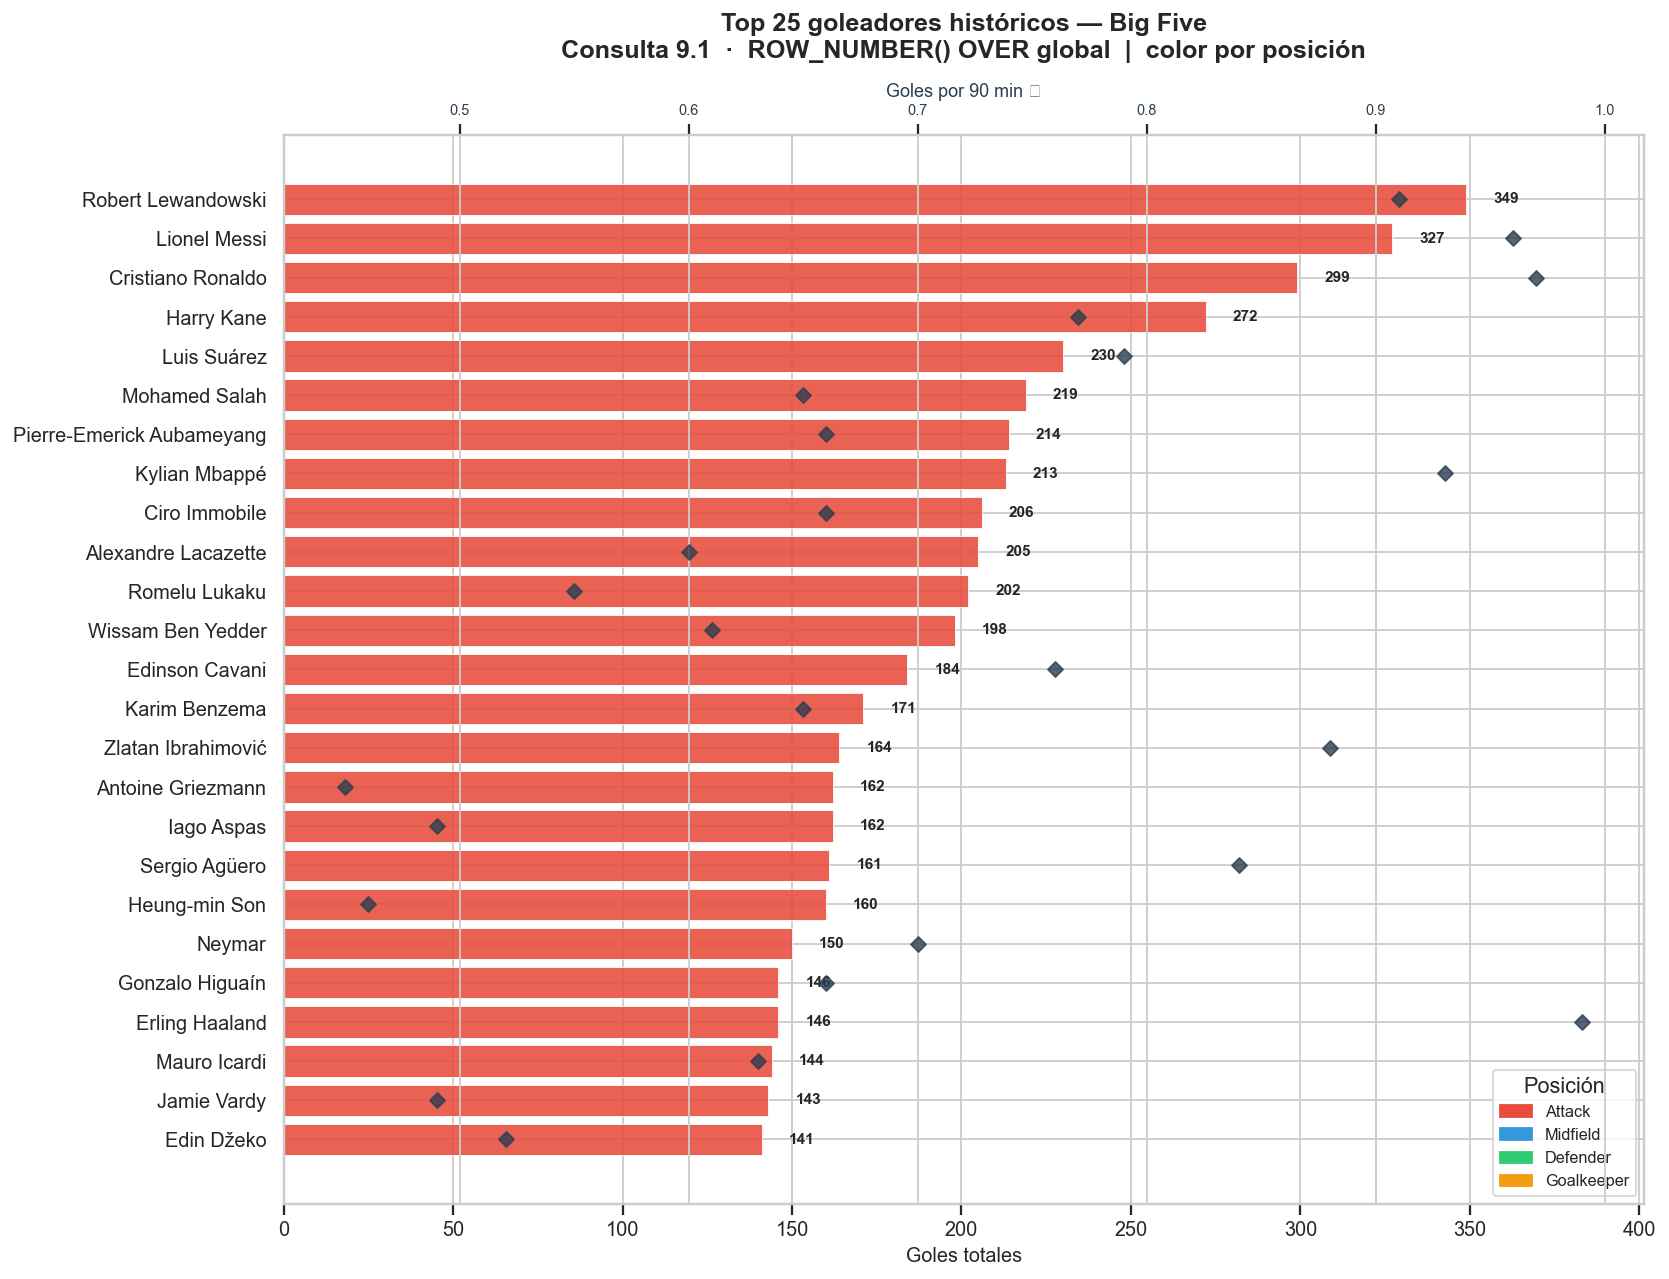

 ranking                   jugador posicion  goles  goles_por_90min
       1        Robert Lewandowski   Attack    349             0.91
       2              Lionel Messi   Attack    327             0.96
       3         Cristiano Ronaldo   Attack    299             0.97
       4                Harry Kane   Attack    272             0.77
       5               Luis Suárez   Attack    230             0.79
       6             Mohamed Salah   Attack    219             0.65
       7 Pierre-Emerick Aubameyang   Attack    214             0.66
       8             Kylian Mbappé   Attack    213             0.93
       9             Ciro Immobile   Attack    206             0.66
      10       Alexandre Lacazette   Attack    205             0.60
      11             Romelu Lukaku   Attack    202             0.55
      12         Wissam Ben Yedder   Attack    198             0.61
      13            Edinson Cavani   Attack    184             0.76
      14             Karim Benzema   Attack    1

In [23]:
# ── Consulta 9.1: Top 25 goleadores históricos (ROW_NUMBER global) ────────────
SQL_TOP25 = """
SELECT
    ROW_NUMBER() OVER (ORDER BY SUM(fa.goals) DESC) AS ranking,
    p.name                                          AS jugador,
    p.position                                      AS posicion,
    p.country_of_citizenship                        AS nacionalidad,
    SUM(fa.goals)                                   AS goles,
    SUM(fa.assists)                                 AS asistencias,
    COUNT(DISTINCT fa.game_id)                      AS partidos,
    ROUND(SUM(fa.goals)::NUMERIC * 90
        / NULLIF(SUM(fa.minutes_played), 0), 2)     AS goles_por_90min
FROM dwh.fact_appearances fa
    INNER JOIN dwh.dim_players p         ON fa.player_id      = p.player_id
    INNER JOIN dwh.dim_clubs c           ON fa.club_id        = c.club_id
    INNER JOIN dwh.dim_competitions comp ON fa.competition_id = comp.competition_id
WHERE fa.competition_id IN ('ES1','GB1','IT1','FR1','L1')
  AND p.player_id != -1
GROUP BY p.name, p.position, p.country_of_citizenship
HAVING SUM(fa.goals) > 0
ORDER BY goles DESC
LIMIT 25;
"""

df_top25 = run_query(SQL_TOP25)
for col in ['goles', 'asistencias', 'partidos']:
    df_top25[col] = pd.to_numeric(df_top25[col], errors='coerce').astype(int)
df_top25['goles_por_90min'] = pd.to_numeric(df_top25['goles_por_90min'], errors='coerce')

# Colores por posición
POS_COLORS = {
    'Attack':     '#e74c3c',
    'Midfield':   '#3498db',
    'Defender':   '#2ecc71',
    'Goalkeeper': '#f39c12',
}
bar_colors = [POS_COLORS.get(p, '#95a5a6') for p in df_top25['posicion']]

fig, ax1 = plt.subplots(figsize=(13, 10))

# Barras horizontales
bars = ax1.barh(df_top25['jugador'], df_top25['goles'],
                color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.88)

# Etiquetas de goles a la derecha de cada barra
for bar, val in zip(bars, df_top25['goles']):
    ax1.text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
             str(int(val)), va='center', fontsize=8.5, fontweight='bold')

# Scatter secundario: goles/90 min en eje superior
ax2 = ax1.twiny()
ax2.scatter(df_top25['goles_por_90min'], df_top25['jugador'],
            color='#2c3e50', marker='D', s=35, zorder=5, alpha=0.8)
ax2.set_xlabel('Goles por 90 min ◆', fontsize=10, color='#2c3e50')
ax2.tick_params(axis='x', labelcolor='#2c3e50', labelsize=8)

ax1.invert_yaxis()
ax1.set_xlabel('Goles totales', fontsize=11)
ax1.set_title(
    'Top 25 goleadores históricos — Big Five\n'
    'Consulta 9.1  ·  ROW_NUMBER() OVER global  |  color por posición',
    fontsize=14, fontweight='bold', pad=14,
)
ax1.set_xlim(0, df_top25['goles'].max() * 1.15)

legend_handles = [mpatches.Patch(color=c, label=p) for p, c in POS_COLORS.items()]
ax1.legend(handles=legend_handles, title='Posición', loc='lower right', fontsize=9)

plt.tight_layout()
save_fig('viz_01_top25_goleadores.png')
plt.show()

print(df_top25[['ranking', 'jugador', 'posicion', 'goles', 'goles_por_90min']].to_string(index=False))


---
## 2. SLICE + CASE WHEN — Factor campo: ¿existe ventaja de jugar en casa?
**Consulta 9.4** · Tablas: `fact_games`, `dim_competitions`

La consulta realiza un **SLICE** sobre `fact_games` filtrando las 5 ligas y usa `CASE WHEN` para pivotar los resultados: una columna por tipo de resultado (victoria local, empate, victoria visitante), calculando cada porcentaje sobre el total de partidos de esa liga. También extrae las medias de goles local y visitante para la mini-tabla comparativa.

- **Filtro:** `competition_id IN ('ES1','GB1','IT1','FR1','L1')` — todos los años disponibles
- **Pivot condicional:** tres bloques `SUM(CASE WHEN ... THEN 1 ELSE 0 END) / COUNT(*)`
- **Ordenación:** `ORDER BY pct_victoria_local DESC` para identificar la liga con mayor ventaja local

> **Nota sobre Python:** `comp.name` devuelve claves lowercase (`'laliga'`, `'premier-league'`…); se mapea a nombres legibles con `LIGA_LABELS` antes de pintar el gráfico.

**Operación OLAP:** `SLICE` · **Visualización:** barras apiladas 100% con etiquetas internas + mini-tabla de goles promedio


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_02_factor_campo.png


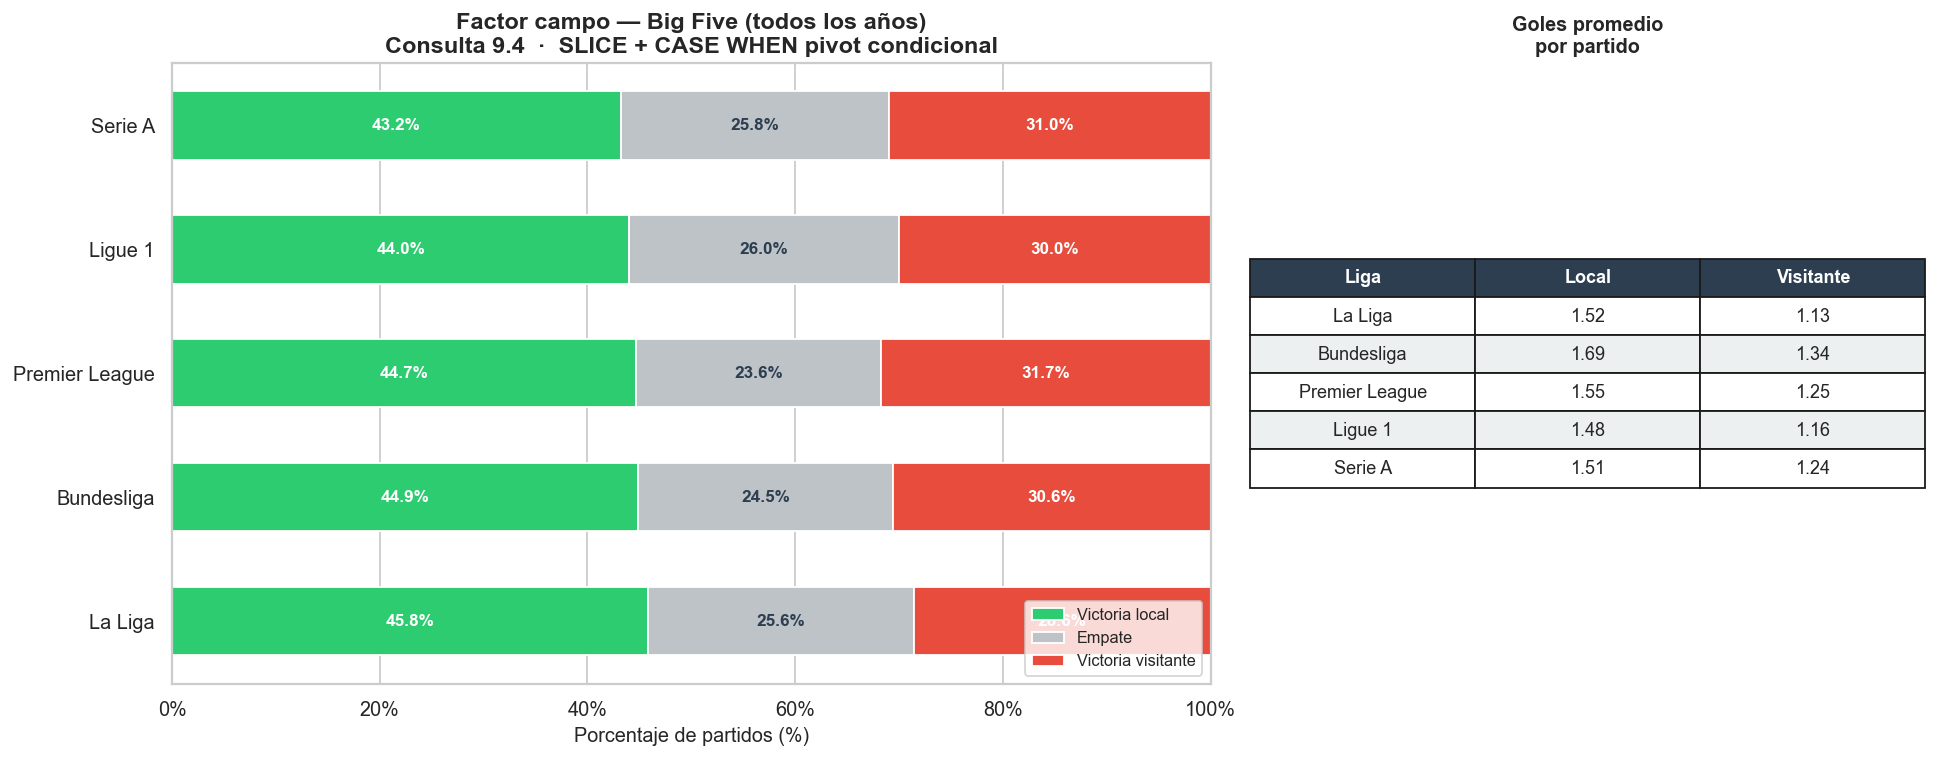

          liga  pct_victoria_local  pct_empate  pct_victoria_visitante
       La Liga                45.8        25.6                    28.6
    Bundesliga                44.9        24.5                    30.6
Premier League                44.7        23.6                    31.7
       Ligue 1                44.0        26.0                    30.0
       Serie A                43.2        25.8                    31.0


In [24]:
# ── Consulta 9.4: Factor campo — barras apiladas 100% ────────────────────────
SQL_CAMPO = """
SELECT
    comp.name                                           AS liga,
    COUNT(*)                                            AS partidos_totales,
    ROUND(100.0 * SUM(CASE WHEN fg.is_home_win THEN 1 ELSE 0 END) / COUNT(*), 1)
                                                        AS pct_victoria_local,
    ROUND(100.0 * SUM(CASE WHEN fg.is_draw THEN 1 ELSE 0 END) / COUNT(*), 1)
                                                        AS pct_empate,
    ROUND(100.0 * SUM(CASE WHEN fg.is_away_win THEN 1 ELSE 0 END) / COUNT(*), 1)
                                                        AS pct_victoria_visitante,
    ROUND(AVG(fg.home_club_goals), 2)                   AS goles_local_promedio,
    ROUND(AVG(fg.away_club_goals), 2)                   AS goles_visitante_promedio
FROM dwh.fact_games fg
    INNER JOIN dwh.dim_competitions comp ON fg.competition_id = comp.competition_id
WHERE fg.competition_id IN ('ES1','GB1','IT1','FR1','L1')
GROUP BY comp.name
ORDER BY pct_victoria_local DESC;
"""

df_campo = run_query(SQL_CAMPO)
for col in ['pct_victoria_local', 'pct_empate', 'pct_victoria_visitante',
            'goles_local_promedio', 'goles_visitante_promedio']:
    df_campo[col] = pd.to_numeric(df_campo[col], errors='coerce')
# comp.name devuelve claves lowercase → mapear a nombres legibles
df_campo['liga'] = df_campo['liga'].map(LIGA_LABELS).fillna(df_campo['liga'])

fig, (ax_main, ax_table) = plt.subplots(1, 2, figsize=(15, 6),
                                         gridspec_kw={'width_ratios': [2, 1]})

# ── Barras apiladas 100% ─────────────────────────────────────────────────────
ligas  = df_campo['liga']
local  = df_campo['pct_victoria_local'].values
empate = df_campo['pct_empate'].values
visita = df_campo['pct_victoria_visitante'].values

y      = np.arange(len(ligas))
height = 0.55

b1 = ax_main.barh(y, local,  height=height, label='Victoria local',     color='#2ecc71')
b2 = ax_main.barh(y, empate, height=height, label='Empate',             color='#bdc3c7', left=local)
b3 = ax_main.barh(y, visita, height=height, label='Victoria visitante',  color='#e74c3c',
                  left=local + empate)

# Etiquetas dentro de cada segmento
for i, (vl, ve, vv) in enumerate(zip(local, empate, visita)):
    if vl > 4:
        ax_main.text(vl / 2, i, f'{vl:.1f}%', ha='center', va='center',
                     fontsize=9.5, color='white', fontweight='bold')
    if ve > 4:
        ax_main.text(vl + ve / 2, i, f'{ve:.1f}%', ha='center', va='center',
                     fontsize=9.5, color='#2c3e50', fontweight='bold')
    if vv > 4:
        ax_main.text(vl + ve + vv / 2, i, f'{vv:.1f}%', ha='center', va='center',
                     fontsize=9.5, color='white', fontweight='bold')

ax_main.set_yticks(y)
ax_main.set_yticklabels(ligas, fontsize=11)
ax_main.set_xlim(0, 100)
ax_main.set_xlabel('Porcentaje de partidos (%)', fontsize=11)
ax_main.set_title(
    'Factor campo — Big Five (todos los años)\n'
    'Consulta 9.4  ·  SLICE + CASE WHEN pivot condicional',
    fontsize=13, fontweight='bold',
)
ax_main.legend(loc='lower right', fontsize=9)
ax_main.xaxis.set_major_formatter(mticker.PercentFormatter())

# ── Mini-tabla: goles promedio ────────────────────────────────────────────────
ax_table.axis('off')
tabla_data = [['Liga', 'Local', 'Visitante']] + [
    [row['liga'][:14], f"{row['goles_local_promedio']:.2f}", f"{row['goles_visitante_promedio']:.2f}"]
    for _, row in df_campo.iterrows()
]
tbl = ax_table.table(cellText=tabla_data[1:], colLabels=tabla_data[0],
                     loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 1.7)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ecf0f1')

ax_table.set_title('Goles promedio\npor partido', fontsize=11, fontweight='bold', pad=6)

plt.tight_layout()
save_fig('viz_02_factor_campo.png')
plt.show()

print(df_campo[['liga', 'pct_victoria_local', 'pct_empate', 'pct_victoria_visitante']].to_string(index=False))


---
## 3. DRILL-DOWN + WINDOW — Pichichi por temporada y liga (2015–2024)
**Consulta 9.5** · Tablas: `fact_appearances`, `dim_players`, `dim_date`, `dim_competitions`

La consulta hace un **Drill-Down** descendiendo desde liga → temporada → jugador. Para cada combinación (liga, temporada) se suman los goles de cada jugador y se aplica `ROW_NUMBER() OVER (PARTITION BY competition_id, season_start_year ORDER BY SUM(goals) DESC, p.name)` para seleccionar al máximo goleador de cada liga en cada temporada. Se usa `ROW_NUMBER` en lugar de `RANK` para evitar empates que romperían el `pivot()` de pandas.

- **Ventana:** `PARTITION BY competition_id, season_start_year` — un ganador por (liga, temporada)
- **Desempate determinista:** `ORDER BY SUM(goals) DESC, p.name` — orden alfabético si hay igualdad de goles
- **Tabla usada:** `competition_id` (en lugar de `comp.name`) para usar como clave de los diccionarios `LIGA_COLORS` / `LIGA_LABELS` directamente mediante `ID_TO_LIGA`

> **Nota sobre Python:** `competition_id` se mapea a nombre de liga con `ID_TO_LIGA` antes del pivot para garantizar correspondencia de claves.

**Operación OLAP:** `DRILL-DOWN` (liga → temporada) + `WINDOW ROW_NUMBER` · **Visualización:** heatmap con anotaciones "Apellido (N goles)"


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_03_pichichi_heatmap.png


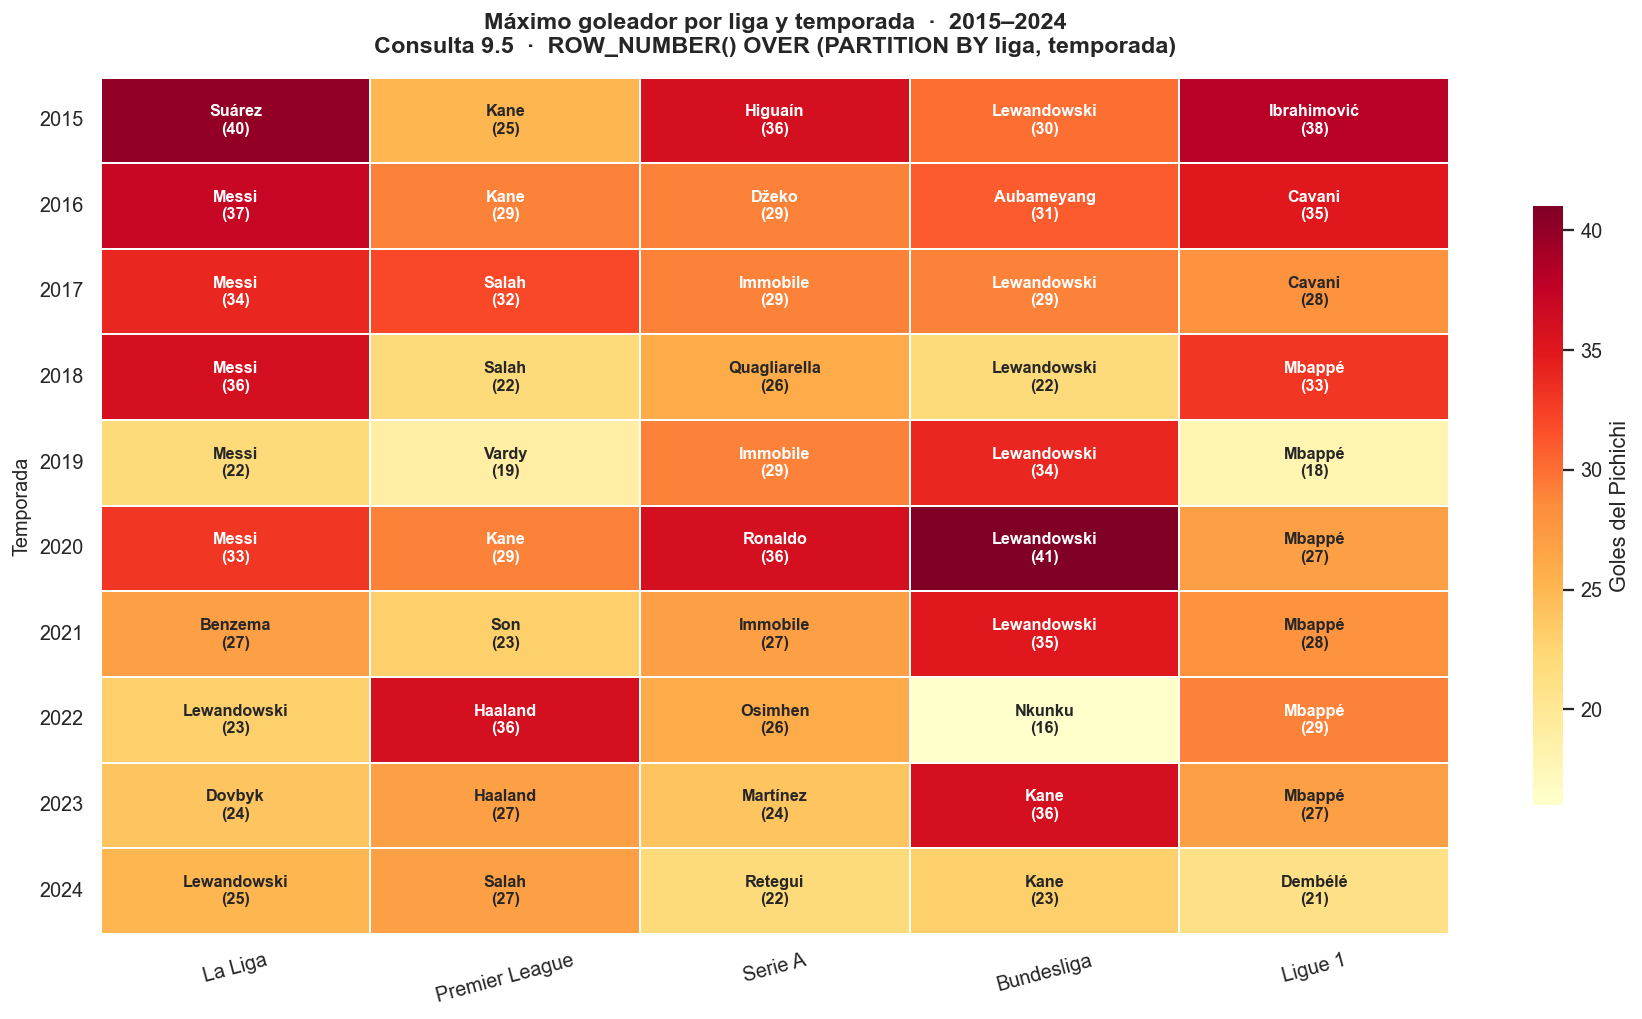

 temporada           liga                   jugador  goles
      2015     bundesliga        Robert Lewandowski     30
      2016     bundesliga Pierre-Emerick Aubameyang     31
      2017     bundesliga        Robert Lewandowski     29
      2018     bundesliga        Robert Lewandowski     22
      2019     bundesliga        Robert Lewandowski     34
      2020     bundesliga        Robert Lewandowski     41
      2021     bundesliga        Robert Lewandowski     35
      2022     bundesliga        Christopher Nkunku     16
      2023     bundesliga                Harry Kane     36
      2024     bundesliga                Harry Kane     23
      2015         laliga               Luis Suárez     40
      2016         laliga              Lionel Messi     37
      2017         laliga              Lionel Messi     34
      2018         laliga              Lionel Messi     36
      2019         laliga              Lionel Messi     22
      2020         laliga              Lionel Messi     

In [25]:
# ── Consulta 9.5: Pichichi por liga y temporada (ROW_NUMBER) ─────────────────
SQL_PICHICHI = """
SELECT liga, temporada, jugador, goles
FROM (
    SELECT
        comp.competition_id                                         AS liga,
        d.season_start_year                                         AS temporada,
        p.name                                                      AS jugador,
        SUM(fa.goals)                                               AS goles,
        ROW_NUMBER() OVER (
            PARTITION BY comp.competition_id, d.season_start_year
            ORDER BY SUM(fa.goals) DESC, p.name
        )                                                           AS rk
    FROM dwh.fact_appearances fa
        INNER JOIN dwh.dim_players p         ON fa.player_id      = p.player_id
        INNER JOIN dwh.dim_date d            ON fa.date_id        = d.date_id
        INNER JOIN dwh.dim_competitions comp ON fa.competition_id = comp.competition_id
    WHERE fa.competition_id IN ('ES1','GB1','IT1','FR1','L1')
      AND p.player_id != -1
      AND d.season_start_year BETWEEN 2015 AND 2024
    GROUP BY comp.competition_id, d.season_start_year, p.name
    HAVING SUM(fa.goals) > 0
) g
WHERE rk = 1
ORDER BY liga, temporada;
"""

# competition_id → nombre de liga (clave para LIGA_COLORS / LIGA_LABELS)
ID_TO_LIGA = {
    'ES1': 'laliga',
    'GB1': 'premier-league',
    'IT1': 'serie-a',
    'FR1': 'ligue-1',
    'L1':  'bundesliga',
}

df_pich = run_query(SQL_PICHICHI)
df_pich['goles']     = df_pich['goles'].astype(int)
df_pich['temporada'] = df_pich['temporada'].astype(int)
df_pich['liga']      = df_pich['liga'].map(ID_TO_LIGA)
df_pich = df_pich.drop_duplicates(subset=['temporada', 'liga'])

# ── Pivot ─────────────────────────────────────────────────────────────────────
pivot_goles = df_pich.pivot(index='temporada', columns='liga', values='goles')
pivot_label = df_pich.pivot(index='temporada', columns='liga', values='jugador')

ordered_cols = [c for c in LIGA_ORDER if c in pivot_goles.columns]
pivot_goles  = pivot_goles[ordered_cols].rename(columns=LIGA_LABELS)
pivot_label  = pivot_label[ordered_cols].rename(columns=LIGA_LABELS)

# ── Anotaciones: "Apellido\n(N goles)" ────────────────────────────────────────
def short_name(name):
    parts = str(name).split()
    return parts[-1] if len(parts) > 1 else name

annot_matrix = pivot_label.copy().astype(object)
for col in pivot_label.columns:
    for idx in pivot_label.index:
        j = pivot_label.at[idx, col]
        g = pivot_goles.at[idx, col]
        annot_matrix.at[idx, col] = (
            f"{short_name(str(j))}\n({int(g)})" if pd.notna(j) and pd.notna(g) else ''
        )

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot_goles.astype(float),
    annot=annot_matrix,
    fmt='',
    cmap='YlOrRd',
    linewidths=1, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Goles del Pichichi', 'shrink': 0.7},
    annot_kws={'size': 9, 'weight': 'bold'},
)
ax.set_title(
    'Máximo goleador por liga y temporada  ·  2015–2024\n'
    'Consulta 9.5  ·  ROW_NUMBER() OVER (PARTITION BY liga, temporada)',
    fontsize=13, fontweight='bold', pad=14,
)
ax.set_xlabel('')
ax.set_ylabel('Temporada', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
save_fig('viz_03_pichichi_heatmap.png')
plt.show()

print(df_pich[['temporada', 'liga', 'jugador', 'goles']].sort_values(['liga', 'temporada']).to_string(index=False))


---
## 4. DICE + CTEs + FULL OUTER JOIN — Balance gastos / ingresos por club
**Consulta 9.6** · Tablas: `fact_transfers`, `dim_clubs`, `dim_competitions`

La consulta define dos CTEs independientes: **`gastos`** suma todos los fichajes donde el club es comprador (`to_club_id`) y **`ingresos`** suma las ventas donde el club es vendedor (`from_club_id`). El `FULL OUTER JOIN` entre ambas garantiza que aparezcan clubs con solo compras o solo ventas. El balance neto es `ingresos - gastos` en M€.

- **DICE:** filtro `competition_id IN ('ES1','GB1','IT1','FR1','L1')` — solo las Big Five
- **FULL OUTER JOIN:** evita perder clubs con actividad exclusiva de compra o venta
- **`FILTER (WHERE transfer_fee > 0)`:** excluye cesiones y fichajes gratuitos del cálculo

> **Nota sobre Python:** Las columnas `gastado_m`, `ingresado_m`, `balance_neto_m` se reciben en minúsculas porque PostgreSQL normaliza los alias a lowercase.

**Operación OLAP:** `DICE` + `CTEs` + `FULL OUTER JOIN` · **Visualización:** barras horizontales divergentes (rojo = déficit, verde = superávit) con indicador de liga por color lateral


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_04_balance_gastos_ingresos.png


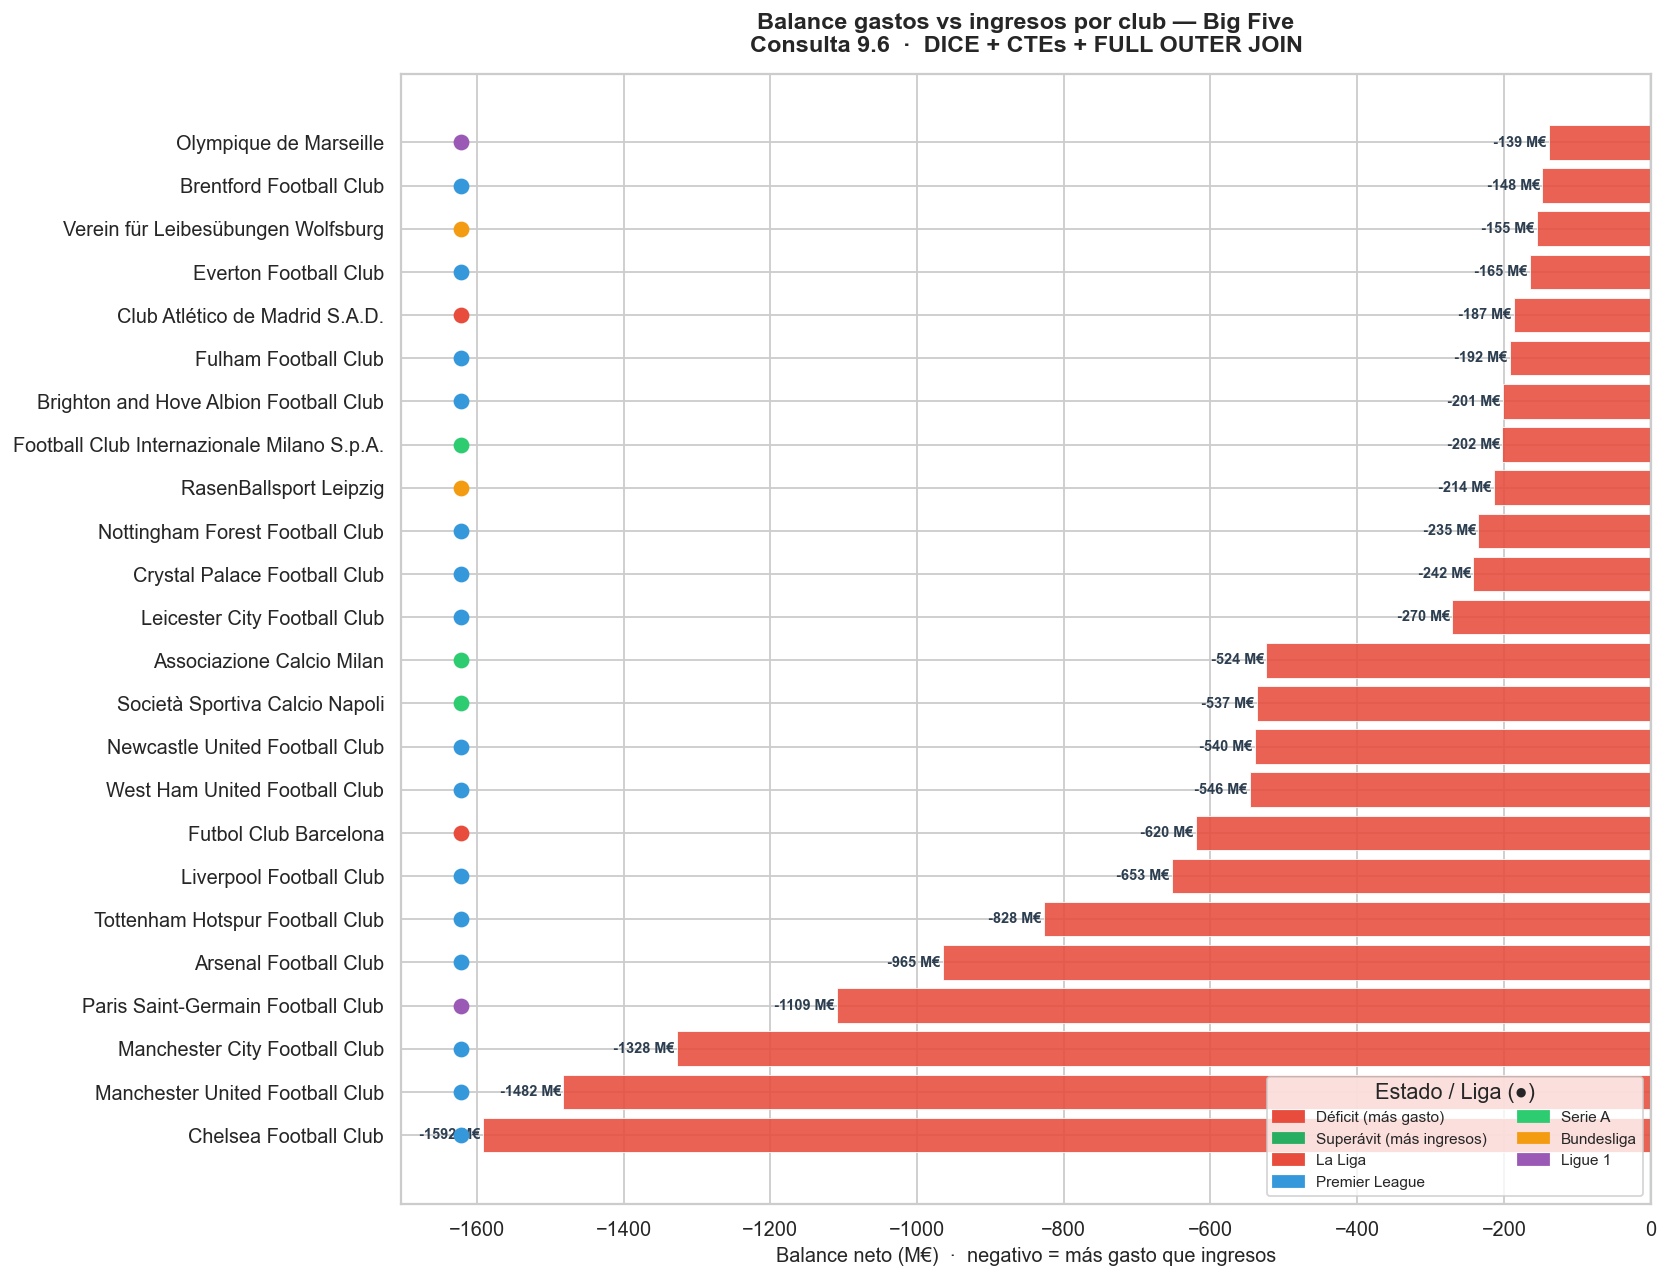

                                      club           liga  gastado_m  ingresado_m  balance_neto_m
                     Chelsea Football Club premier-league     2521.8        930.0         -1591.8
           Manchester United Football Club premier-league     1967.5        485.2         -1482.3
             Manchester City Football Club premier-league     2092.1        764.4         -1327.8
         Paris Saint-Germain Football Club        ligue-1     1587.8        479.2         -1108.7
                     Arsenal Football Club premier-league     1365.8        400.6          -965.2
           Tottenham Hotspur Football Club premier-league     1333.0        505.5          -827.5
                   Liverpool Football Club premier-league     1130.5        477.9          -652.6
                     Futbol Club Barcelona         laliga     1338.8        718.8          -620.0
             West Ham United Football Club premier-league      918.3        372.2          -546.1
            Newcastl

In [26]:
# ── Consulta 9.6: Balance gastos / ingresos por club (FULL OUTER JOIN) ────────
# Nota: PostgreSQL devuelve alias en minúsculas → gastado_m, ingresado_m, balance_neto_m
SQL_BALANCE = """
WITH gastos AS (
    SELECT
        c.name                                              AS club,
        comp.competition_id                                 AS liga_id,
        SUM(t.transfer_fee) FILTER (WHERE t.transfer_fee > 0) AS total_gastado
    FROM dwh.fact_transfers t
        INNER JOIN dwh.dim_clubs c ON t.to_club_id = c.club_id
        LEFT  JOIN dwh.dim_competitions comp ON c.domestic_competition_id = comp.competition_id
    WHERE c.club_id != -1
      AND comp.competition_id IN ('ES1','GB1','IT1','FR1','L1')
    GROUP BY c.name, comp.competition_id
),
ingresos AS (
    SELECT
        c.name                                              AS club,
        comp.competition_id                                 AS liga_id,
        SUM(t.transfer_fee) FILTER (WHERE t.transfer_fee > 0) AS total_ingresado
    FROM dwh.fact_transfers t
        INNER JOIN dwh.dim_clubs c ON t.from_club_id = c.club_id
        LEFT  JOIN dwh.dim_competitions comp ON c.domestic_competition_id = comp.competition_id
    WHERE c.club_id != -1
      AND comp.competition_id IN ('ES1','GB1','IT1','FR1','L1')
    GROUP BY c.name, comp.competition_id
)
SELECT
    COALESCE(g.club,    i.club)                                             AS club,
    COALESCE(g.liga_id, i.liga_id)                                          AS liga_id,
    ROUND(COALESCE(g.total_gastado,   0)::NUMERIC / 1e6, 1)                AS gastado_m,
    ROUND(COALESCE(i.total_ingresado, 0)::NUMERIC / 1e6, 1)                AS ingresado_m,
    ROUND((COALESCE(i.total_ingresado, 0) - COALESCE(g.total_gastado, 0))::NUMERIC / 1e6, 1)
                                                                            AS balance_neto_m
FROM gastos g
    FULL OUTER JOIN ingresos i ON g.club = i.club
ORDER BY balance_neto_m ASC
LIMIT 30;
"""

ID_TO_LIGA = {'ES1': 'laliga', 'GB1': 'premier-league', 'IT1': 'serie-a',
              'FR1': 'ligue-1', 'L1': 'bundesliga'}

df_bal = run_query(SQL_BALANCE)
for col in ['gastado_m', 'ingresado_m', 'balance_neto_m']:
    df_bal[col] = pd.to_numeric(df_bal[col], errors='coerce')
df_bal['liga'] = df_bal['liga_id'].map(ID_TO_LIGA)

# 12 mayores déficits + 12 mayores superávits
n = 12
df_plot = pd.concat([
    df_bal.nsmallest(n, 'balance_neto_m'),
    df_bal.nlargest(n,  'balance_neto_m'),
]).drop_duplicates('club').sort_values('balance_neto_m')

colors = ['#e74c3c' if v < 0 else '#27ae60' for v in df_plot['balance_neto_m']]

fig, ax = plt.subplots(figsize=(13, 10))
bars = ax.barh(df_plot['club'], df_plot['balance_neto_m'],
               color=colors, edgecolor='white', linewidth=0.5, alpha=0.88)
ax.axvline(0, color='#2c3e50', linewidth=1.2)

for bar, val, liga in zip(bars, df_plot['balance_neto_m'], df_plot['liga']):
    xpos = bar.get_width() + (3 if val >= 0 else -3)
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{val:+.0f} M€', va='center', ha=ha,
            fontsize=8, fontweight='bold', color='#2c3e50')
    ax.scatter(df_plot['balance_neto_m'].min() - 30,
               bar.get_y() + bar.get_height() / 2,
               color=LIGA_COLORS.get(liga, '#95a5a6'), s=60, zorder=5, clip_on=False)

ax.set_xlabel('Balance neto (M€)  ·  negativo = más gasto que ingresos', fontsize=11)
ax.set_title(
    'Balance gastos vs ingresos por club — Big Five\n'
    'Consulta 9.6  ·  DICE + CTEs + FULL OUTER JOIN',
    fontsize=13, fontweight='bold', pad=12,
)

deficit_p   = mpatches.Patch(color='#e74c3c', label='Déficit (más gasto)')
superavit_p = mpatches.Patch(color='#27ae60', label='Superávit (más ingresos)')
liga_handles = [mpatches.Patch(color=c, label=LIGA_LABELS[l]) for l, c in LIGA_COLORS.items()]
ax.legend(handles=[deficit_p, superavit_p] + liga_handles,
          loc='lower right', fontsize=8.5, ncol=2, title='Estado / Liga (●)')

plt.tight_layout()
save_fig('viz_04_balance_gastos_ingresos.png')
plt.show()

print(df_plot[['club', 'liga', 'gastado_m', 'ingresado_m', 'balance_neto_m']].to_string(index=False))


---
## 5. SLICE + CASE WHEN — Distribución de goles por franja de minuto
**Consulta 9.7** · Tablas: `fact_game_events`, `dim_competitions`

La consulta hace un **SLICE** sobre `fact_game_events` filtrando únicamente los eventos de tipo `'Goals'` en las Big Five. Un bloque `CASE WHEN` clasifica cada gol en una franja de 15 minutos (01-15, 16-30, 31-45, 46-60, 61-75, 76-90, 90+). La función de ventana `SUM(COUNT(*)) OVER ()` sobre el `COUNT(*)` agrupado permite calcular el porcentaje de cada franja sobre el total en una sola pasada.

- **Filtro:** `type = 'Goals'` y `minute > 0` — excluye otros eventos y registros sin minuto
- **CASE WHEN doble:** tanto en el `SELECT` como en el `GROUP BY` (PostgreSQL no permite alias en `GROUP BY`)
- **`OVER ()`:** ventana sin partition → denominator es el total absoluto de goles

**Operación OLAP:** `SLICE` (Big Five, type=Goals) · **Visualización:** barras con degradado de color (verde 1ª parte → azul 2ª parte → rojo añadido) + línea de media por franja


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_05_goles_por_minuto.png


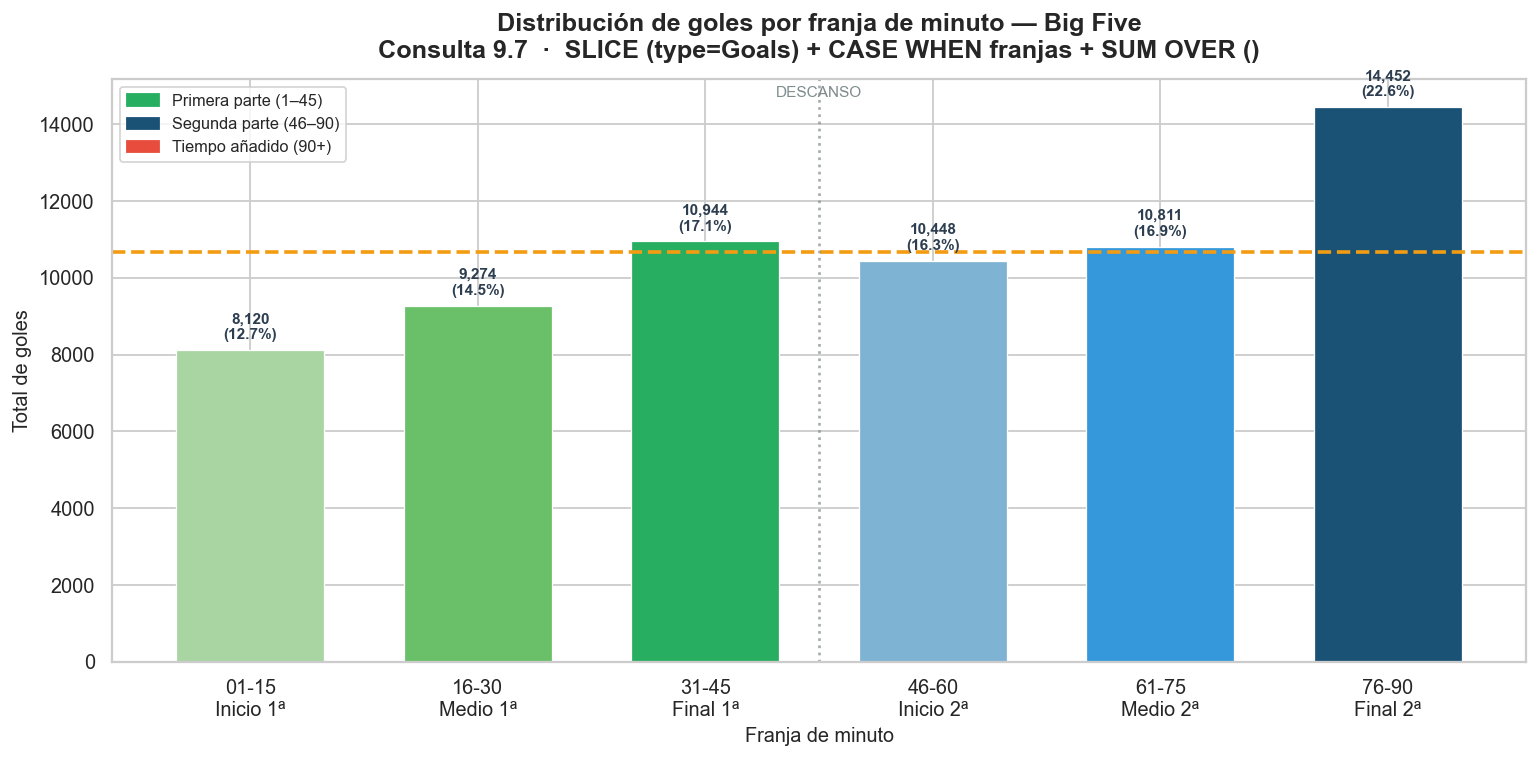

franja  total_goles  porcentaje
 01-15         8120        12.7
 16-30         9274        14.5
 31-45        10944        17.1
 46-60        10448        16.3
 61-75        10811        16.9
 76-90        14452        22.6


In [27]:
# ── Consulta 9.7: Distribución de goles por franja de minuto ─────────────────
SQL_MINUTOS = """
SELECT
    CASE
        WHEN ge.minute BETWEEN 1  AND 15  THEN '01-15'
        WHEN ge.minute BETWEEN 16 AND 30  THEN '16-30'
        WHEN ge.minute BETWEEN 31 AND 45  THEN '31-45'
        WHEN ge.minute BETWEEN 46 AND 60  THEN '46-60'
        WHEN ge.minute BETWEEN 61 AND 75  THEN '61-75'
        WHEN ge.minute BETWEEN 76 AND 90  THEN '76-90'
        WHEN ge.minute > 90               THEN '90+'
        ELSE 'Desc.'
    END                                             AS franja,
    COUNT(*)                                        AS total_goles,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS porcentaje
FROM dwh.fact_game_events ge
WHERE ge.type = 'Goals'
  AND ge.competition_id IN ('ES1','GB1','IT1','FR1','L1')
  AND ge.minute > 0
GROUP BY
    CASE
        WHEN ge.minute BETWEEN 1  AND 15  THEN '01-15'
        WHEN ge.minute BETWEEN 16 AND 30  THEN '16-30'
        WHEN ge.minute BETWEEN 31 AND 45  THEN '31-45'
        WHEN ge.minute BETWEEN 46 AND 60  THEN '46-60'
        WHEN ge.minute BETWEEN 61 AND 75  THEN '61-75'
        WHEN ge.minute BETWEEN 76 AND 90  THEN '76-90'
        WHEN ge.minute > 90               THEN '90+'
        ELSE 'Desc.'
    END
ORDER BY MIN(ge.minute);
"""

df_min = run_query(SQL_MINUTOS)
df_min['total_goles'] = df_min['total_goles'].astype(int)
df_min['porcentaje']  = pd.to_numeric(df_min['porcentaje'], errors='coerce')

# Etiquetas descriptivas para el eje X
labels_full = {
    '01-15': '01-15\nInicio 1ª',
    '16-30': '16-30\nMedio 1ª',
    '31-45': '31-45\nFinal 1ª',
    '46-60': '46-60\nInicio 2ª',
    '61-75': '61-75\nMedio 2ª',
    '76-90': '76-90\nFinal 2ª',
    '90+':   '90+\nAñadido',
}
df_min['label'] = df_min['franja'].map(labels_full).fillna(df_min['franja'])

# Degradado de colores: verde (1ª parte) → azul (2ª parte) → rojo (añadido)
colors_franja = {
    '01-15': '#a8d5a2', '16-30': '#6abf69', '31-45': '#27ae60',
    '46-60': '#7fb3d3', '61-75': '#3498db', '76-90': '#1a5276',
    '90+':   '#e74c3c',
}
bar_colors = [colors_franja.get(f, '#95a5a6') for f in df_min['franja']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(df_min['label'], df_min['total_goles'],
              color=bar_colors, edgecolor='white', linewidth=0.7, width=0.65)

# Etiquetas encima de cada barra
for bar, val, pct in zip(bars, df_min['total_goles'], df_min['porcentaje']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#2c3e50')

# Línea de media por franja
media = df_min['total_goles'].mean()
ax.axhline(media, color='#f39c12', linewidth=2, linestyle='--',
           label=f'Media por franja ({media:,.0f})')

ax.set_ylabel('Total de goles', fontsize=11)
ax.set_xlabel('Franja de minuto', fontsize=11)
ax.set_title(
    'Distribución de goles por franja de minuto — Big Five\n'
    'Consulta 9.7  ·  SLICE (type=Goals) + CASE WHEN franjas + SUM OVER ()',
    fontsize=14, fontweight='bold', pad=12,
)

legend_handles = [
    mpatches.Patch(color='#27ae60', label='Primera parte (1–45)'),
    mpatches.Patch(color='#1a5276', label='Segunda parte (46–90)'),
    mpatches.Patch(color='#e74c3c', label='Tiempo añadido (90+)'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='upper left')

# Separador visual mitad del partido
ax.axvline(2.5, color='#7f8c8d', linewidth=1.5, linestyle=':', alpha=0.7)
ax.text(2.5, ax.get_ylim()[1] * 0.97, 'DESCANSO', ha='center', fontsize=8.5, color='#7f8c8d')

plt.tight_layout()
save_fig('viz_05_goles_por_minuto.png')
plt.show()

print(df_min[['franja', 'total_goles', 'porcentaje']].to_string(index=False))


---
## 6. ROLL-UP + LAG — Inflación del mercado de fichajes (2012–2025)
**Consulta 9.9** · Tablas: `fact_transfers`, `dim_date`

La consulta hace un **Roll-Up temporal** al nivel de año (`d.year`) sobre `fact_transfers`. Para cada año calcula el precio medio con `AVG()`, la mediana con `PERCENTILE_CONT(0.5)` y el total de mercado con `SUM()`, todos aplicados solo a transferencias con precio conocido (`FILTER (WHERE transfer_fee > 0)`). Una subconsulta CTE (`base`) encapsula los agregados y permite usar `LAG(precio_medio_m) OVER (ORDER BY anio)` para calcular la variación interanual porcentual en un segundo pase.

- **`PERCENTILE_CONT(0.5)`:** calcula la mediana exacta (percentil continuo) — función de ordenación, no window
- **`LAG(...) OVER (ORDER BY anio)`:** accede al valor del año anterior sin self-join
- **`NULLIF(..., 0)`:** evita división por cero en el primer año (LAG devuelve NULL → el resultado es NULL, no error)

> **Nota sobre Python:** Las columnas `precio_medio_m`, `mediana_m`, `maximo_m`, `total_mercado_m` se reciben en minúsculas (PostgreSQL normaliza alias a lowercase).

**Operación OLAP:** `ROLL-UP` temporal + `WINDOW LAG` · **Visualización:** barras de precio medio + línea de mediana + eje secundario de variación %, con anotación del crash COVID-19


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_06_inflacion_mercado.png


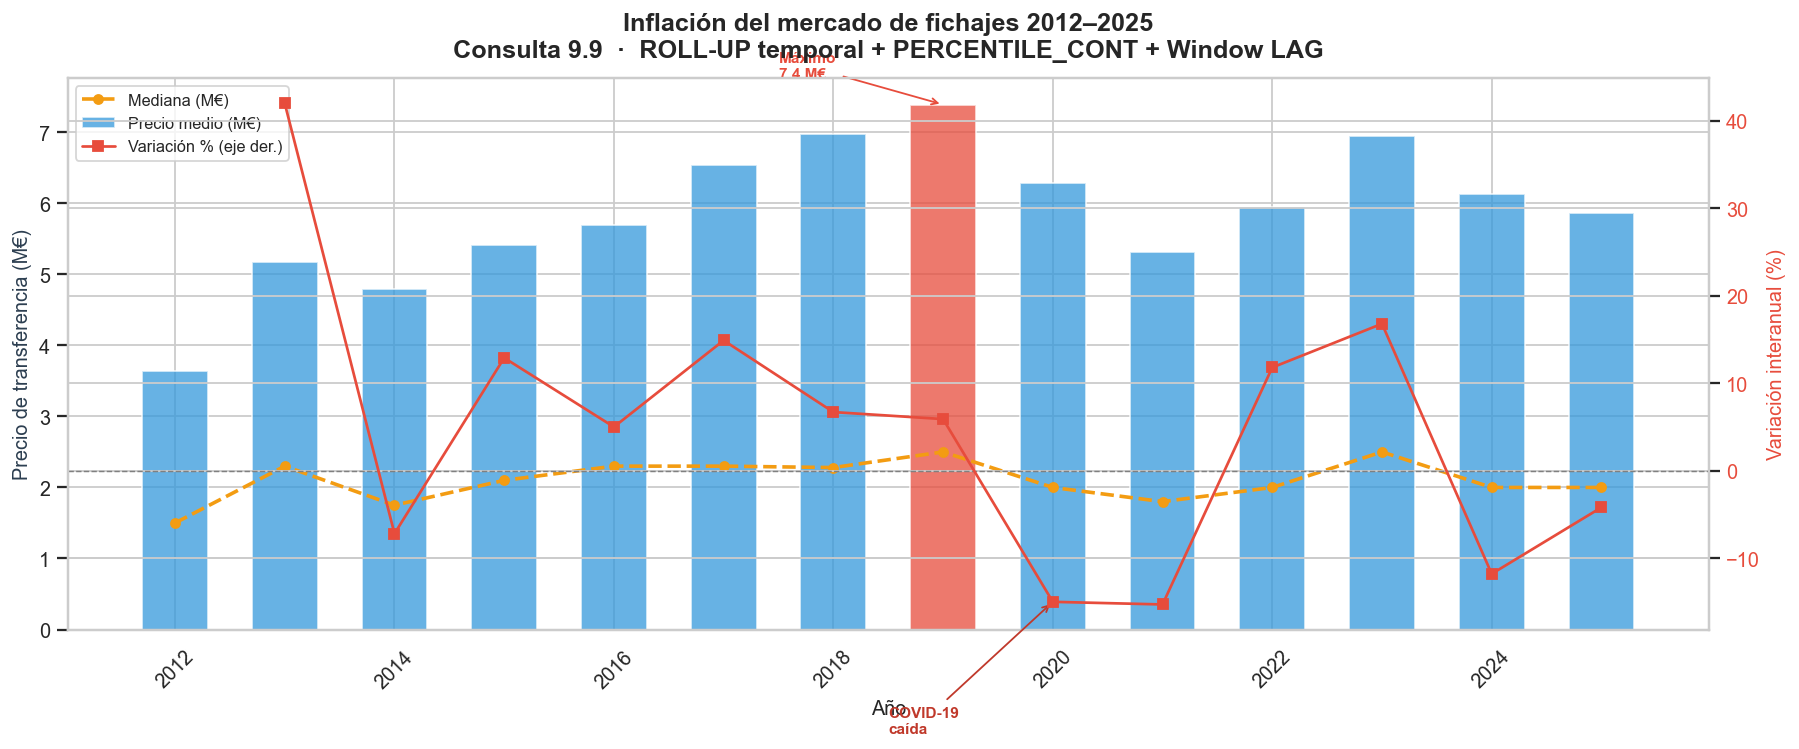

 anio  precio_medio_m  mediana_m  total_mercado_m  variacion_pct
 2012            3.64       1.50            579.4            NaN
 2013            5.17       2.30           1343.6           42.0
 2014            4.80       1.75           1363.1           -7.2
 2015            5.42       2.10           2172.6           12.9
 2016            5.69       2.30           2708.1            5.0
 2017            6.54       2.30           4087.9           14.9
 2018            6.98       2.28           4731.5            6.7
 2019            7.39       2.50           6440.0            5.9
 2020            6.28       2.00           4638.2          -15.0
 2021            5.32       1.80           4025.5          -15.3
 2022            5.95       2.00           6543.3           11.8
 2023            6.95       2.50           8765.4           16.8
 2024            6.13       2.00           7361.9          -11.8
 2025            5.87       2.00           1720.2           -4.2


In [28]:
# ── Consulta 9.9: Inflación del mercado de fichajes (ROLL-UP + LAG) ──────────
# Nota: PostgreSQL devuelve alias en minúsculas → precio_medio_m, mediana_m, etc.
SQL_INFLACION = """
WITH base AS (
    SELECT
        d.year                                              AS anio,
        COUNT(*) FILTER (WHERE t.transfer_fee > 0)          AS num_fichajes_con_precio,
        ROUND((AVG(t.transfer_fee) FILTER (WHERE t.transfer_fee > 0))::NUMERIC / 1e6, 2)
                                                            AS precio_medio_m,
        ROUND((PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY t.transfer_fee)
              FILTER (WHERE t.transfer_fee > 0))::NUMERIC / 1e6, 2)
                                                            AS mediana_m,
        ROUND(MAX(t.transfer_fee)::NUMERIC / 1e6, 1)        AS maximo_m,
        ROUND((SUM(t.transfer_fee) FILTER (WHERE t.transfer_fee > 0))::NUMERIC / 1e6, 1)
                                                            AS total_mercado_m
    FROM dwh.fact_transfers t
        INNER JOIN dwh.dim_date d ON t.transfer_date_id = d.date_id
    WHERE d.year BETWEEN 2012 AND 2025
    GROUP BY d.year
)
SELECT
    anio,
    num_fichajes_con_precio,
    precio_medio_m,
    mediana_m,
    maximo_m,
    total_mercado_m,
    ROUND(100.0 * (precio_medio_m - LAG(precio_medio_m) OVER (ORDER BY anio))
        / NULLIF(LAG(precio_medio_m) OVER (ORDER BY anio), 0), 1) AS variacion_pct
FROM base
ORDER BY anio;
"""

df_inf = run_query(SQL_INFLACION)
for col in ['precio_medio_m', 'mediana_m', 'maximo_m', 'total_mercado_m', 'variacion_pct']:
    df_inf[col] = pd.to_numeric(df_inf[col], errors='coerce')

fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras: precio medio (rojo = máximo histórico)
bar_colors = ['#e74c3c' if v == df_inf['precio_medio_m'].max() else '#3498db'
              for v in df_inf['precio_medio_m']]
bars = ax1.bar(df_inf['anio'], df_inf['precio_medio_m'],
               color=bar_colors, alpha=0.75, label='Precio medio (M€)', width=0.6)

# Línea: mediana
ax1.plot(df_inf['anio'], df_inf['mediana_m'], 'o--', color='#f39c12',
         linewidth=2, markersize=5, label='Mediana (M€)', zorder=5)

ax1.set_ylabel('Precio de transferencia (M€)', fontsize=11, color='#2c3e50')
ax1.set_xlabel('Año', fontsize=11)
ax1.tick_params(axis='x', rotation=45)

# Eje derecho: variación interanual %
ax2 = ax1.twinx()
df_var = df_inf.dropna(subset=['variacion_pct'])
ax2.plot(df_var['anio'], df_var['variacion_pct'], 's-', color='#e74c3c',
         linewidth=1.5, markersize=6, label='Variación % (eje der.)', zorder=4)
ax2.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Variación interanual (%)', fontsize=11, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Anotación COVID-19
covid_y = df_var.loc[df_var['anio'] == 2020, 'variacion_pct']
if not covid_y.empty:
    ax2.annotate('COVID-19\ncaída', xy=(2020, float(covid_y.iloc[0])),
                 xytext=(2018.5, float(covid_y.iloc[0]) - 15),
                 arrowprops=dict(arrowstyle='->', color='#c0392b'),
                 fontsize=8.5, color='#c0392b', fontweight='bold')

# Anotación máximo histórico
max_year = int(df_inf.loc[df_inf['precio_medio_m'].idxmax(), 'anio'])
max_val  = float(df_inf['precio_medio_m'].max())
ax1.annotate(f'Máximo\n{max_val:.1f} M€', xy=(max_year, max_val),
             xytext=(max_year - 1.5, max_val * 1.05),
             arrowprops=dict(arrowstyle='->', color='#e74c3c'),
             fontsize=8.5, color='#e74c3c', fontweight='bold')

ax1.set_title(
    'Inflación del mercado de fichajes 2012–2025\n'
    'Consulta 9.9  ·  ROLL-UP temporal + PERCENTILE_CONT + Window LAG',
    fontsize=14, fontweight='bold', pad=12,
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
save_fig('viz_06_inflacion_mercado.png')
plt.show()

print(df_inf[['anio', 'precio_medio_m', 'mediana_m', 'total_mercado_m', 'variacion_pct']].to_string(index=False))


---
## 7. DICE + 3 CTEs — Radar Chart KPI Big Five
**Consulta 9.10** · Tablas: `fact_games`, `fact_transfers`, `fact_appearances`, `dim_clubs`, `dim_competitions`

La consulta construye tres CTEs independientes que calculan un KPI diferente por liga: **`goles_liga`** (goles por partido y asistencia media desde `fact_games`), **`fichajes_liga`** (precio medio de transferencias desde `fact_transfers` + `dim_clubs`) y **`tarjetas_liga`** (porcentaje de tarjetas amarillas sobre apariciones desde `fact_appearances`). La consulta principal hace `INNER JOIN` + dos `LEFT JOIN` entre las CTEs para consolidar los 4 KPIs en una fila por liga.

- **DICE:** `competition_id IN ('ES1','GB1','IT1','FR1','L1')` en las tres CTEs
- **`FILTER (WHERE transfer_fee > 0)`:** excluye cesiones del precio medio de fichajes
- **`FILTER (WHERE attendance > 0)`:** excluye partidos sin datos de aforo
- **Normalización Python:** cada KPI se escala a [0,1] con `(valor - min) / (max - min)`; "tarjetas %" se invierte (`1 - normed`) porque menos tarjetas es mejor

> **Nota sobre Python:** `fichaje_medio_m` recibido en minúsculas (PostgreSQL).

**Operación OLAP:** `DICE` (5 ligas × 5 KPIs) + múltiples CTEs · **Visualización:** radar chart polar con relleno semitransparente por liga


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_07_radar_big5.png


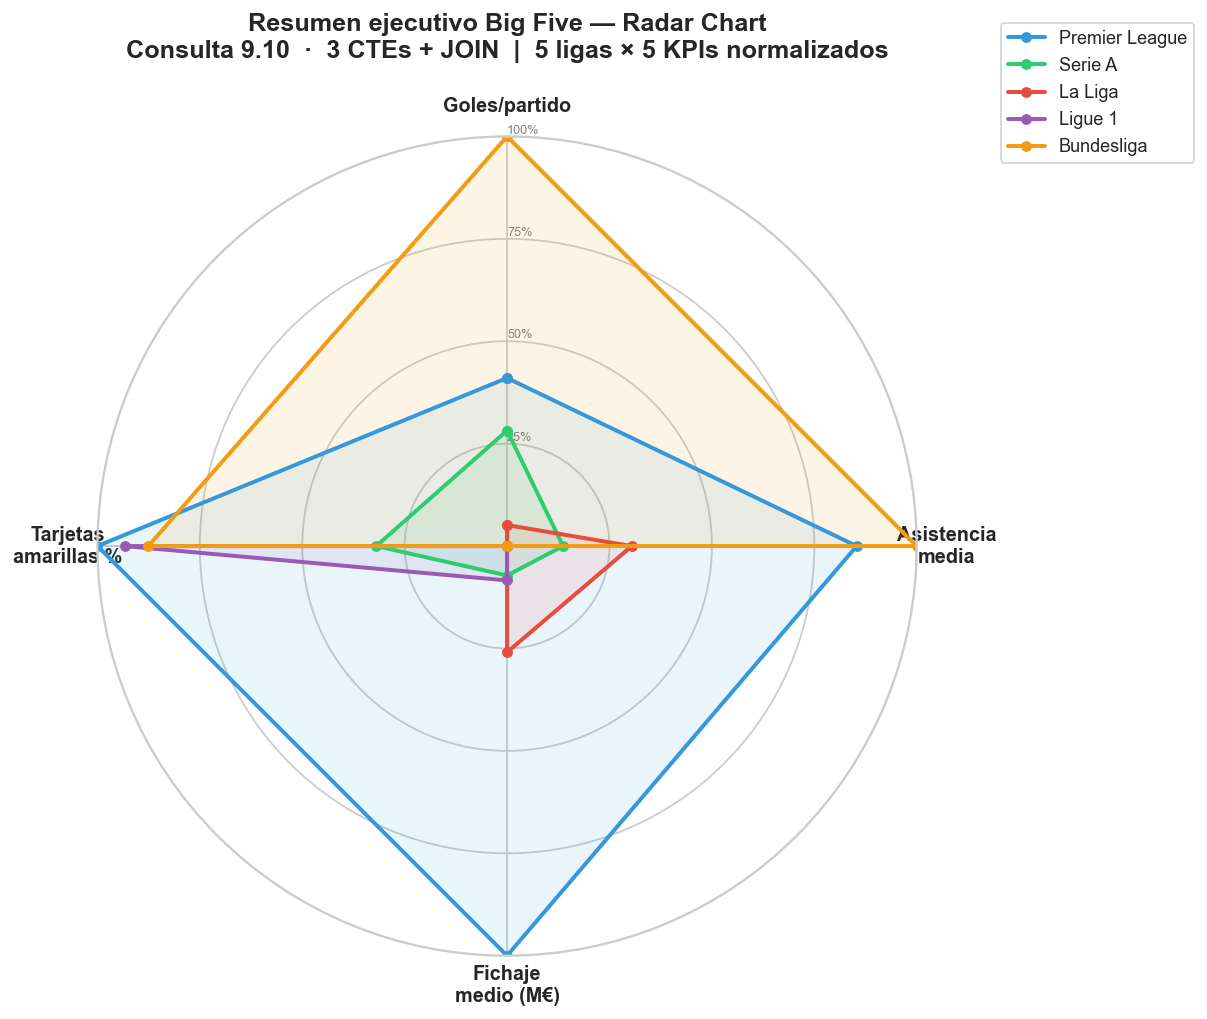

          liga  goles_por_partido  asistencia_media  fichaje_medio_m  pct_amarilla_por_aparicion
premier-league               2.80           37681.0            16.08                       12.50
       serie-a               2.75           24678.0             7.56                       16.06
        laliga               2.66           27722.0             9.28                       17.73
       ligue-1               2.64           22196.0             7.67                       12.85
    bundesliga               3.03           40340.0             6.90                       13.15


In [29]:
# ── Consulta 9.10: Radar Chart KPI Big Five (3 CTEs + JOIN) ─────────────────
# Nota: PostgreSQL devuelve alias en minúsculas → fichaje_medio_m
SQL_BIG5 = """
WITH goles_liga AS (
    SELECT
        fg.competition_id,
        COUNT(*)                                        AS partidos,
        SUM(fg.total_goals)                             AS goles,
        ROUND(AVG(fg.total_goals)::NUMERIC, 2)          AS goles_por_partido,
        ROUND((AVG(fg.attendance) FILTER (WHERE fg.attendance > 0))::NUMERIC, 0)
                                                        AS asistencia_media
    FROM dwh.fact_games fg
    WHERE fg.competition_id IN ('ES1','GB1','IT1','FR1','L1')
    GROUP BY fg.competition_id
),
fichajes_liga AS (
    SELECT
        comp.competition_id,
        ROUND((AVG(t.transfer_fee) FILTER (WHERE t.transfer_fee > 0))::NUMERIC / 1e6, 2)
                                                        AS fichaje_medio_m
    FROM dwh.fact_transfers t
        INNER JOIN dwh.dim_clubs c ON t.to_club_id = c.club_id
        LEFT JOIN dwh.dim_competitions comp ON c.domestic_competition_id = comp.competition_id
    WHERE comp.competition_id IN ('ES1','GB1','IT1','FR1','L1')
      AND c.club_id != -1
    GROUP BY comp.competition_id
),
tarjetas_liga AS (
    SELECT
        fa.competition_id,
        ROUND(100.0 * SUM(fa.yellow_cards) / NULLIF(COUNT(*), 0), 2)
                                                        AS pct_amarilla_por_aparicion
    FROM dwh.fact_appearances fa
    WHERE fa.competition_id IN ('ES1','GB1','IT1','FR1','L1')
    GROUP BY fa.competition_id
)
SELECT
    comp.name                                           AS liga,
    g.goles_por_partido,
    g.asistencia_media,
    f.fichaje_medio_m,
    t.pct_amarilla_por_aparicion
FROM goles_liga g
    INNER JOIN dwh.dim_competitions comp ON g.competition_id = comp.competition_id
    LEFT JOIN fichajes_liga f ON g.competition_id = f.competition_id
    LEFT JOIN tarjetas_liga t ON g.competition_id = t.competition_id
ORDER BY g.goles DESC;
"""

df_big5 = run_query(SQL_BIG5)
for col in ['goles_por_partido', 'asistencia_media', 'fichaje_medio_m', 'pct_amarilla_por_aparicion']:
    df_big5[col] = pd.to_numeric(df_big5[col], errors='coerce')

# Normalizar cada KPI al rango [0,1]
kpi_labels = ['Goles/partido', 'Asistencia\nmedia', 'Fichaje\nmedio (M€)', 'Tarjetas\namarillas %']

def normalize(col: pd.Series, invert: bool = False) -> pd.Series:
    mn, mx = col.min(), col.max()
    normed = (col - mn) / (mx - mn)
    return 1 - normed if invert else normed

df_norm = pd.DataFrame({
    'liga':                  df_big5['liga'],
    'Goles/partido':         normalize(df_big5['goles_por_partido']),
    'Asistencia\nmedia':     normalize(df_big5['asistencia_media']),
    'Fichaje\nmedio (M€)':   normalize(df_big5['fichaje_medio_m']),
    'Tarjetas\namarillas %': normalize(df_big5['pct_amarilla_por_aparicion'], invert=True),
})

categories = kpi_labels
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # cerrar el polígono

fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_rlabel_position(0)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7, color='grey')
ax.set_ylim(0, 1)

# Una línea por liga
for _, row in df_norm.iterrows():
    liga  = row['liga']
    color = LIGA_COLORS.get(liga, '#95a5a6')
    vals  = [row[c] for c in categories] + [row[categories[0]]]
    ax.plot(angles, vals, 'o-', linewidth=2.2, color=color,
            label=LIGA_LABELS.get(liga, liga), markersize=5)
    ax.fill(angles, vals, alpha=0.10, color=color)

ax.set_title(
    'Resumen ejecutivo Big Five — Radar Chart\n'
    'Consulta 9.10  ·  3 CTEs + JOIN  |  5 ligas × 5 KPIs normalizados',
    fontsize=14, fontweight='bold', pad=22,
)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

plt.tight_layout()
save_fig('viz_07_radar_big5.png')
plt.show()

print(df_big5[['liga', 'goles_por_partido', 'asistencia_media', 'fichaje_medio_m', 'pct_amarilla_por_aparicion']].to_string(index=False))


---
## 8. DICE + CTEs + NTILE — Inversión en fichajes vs % de victorias (2018–2024)
**Consulta 12.2** · Tablas: `fact_transfers`, `fact_games`, `dim_clubs`, `dim_competitions`, `dim_date`

La consulta usa dos CTEs: **`gasto_por_club`** suma el gasto total en transferencias por club comprador (2018–2024), y **`resultados_por_club`** agrega victorias y partidos totales usando `UNION ALL` para combinar partidos como local y visitante. Finalmente, `NTILE(4) OVER (ORDER BY gasto_total DESC)` divide los clubs en cuartiles de gasto para codificar el tamaño del punto en el scatter plot.

- **`UNION ALL`:** necesario para contar victorias tanto de local como de visitante en la misma tabla `fact_games` (un partido tiene dos clubs)
- **`NTILE(4)`:** función de ventana que asigna cuartil 1 (más gasto) a 4 (menos gasto)
- **Filtro mínimo:** `WHERE partidos_totales >= 50` — excluye clubs con escasa muestra estadística
- **`LIMIT 30`:** los 30 clubs con mayor gasto total

> **Nota sobre Python:** `gasto_m` recibido en minúsculas (PostgreSQL). Los colores de punto vienen de `LIGA_COLORS` usando las claves lowercase de `comp.name`.

**Operación OLAP:** `DICE` (Big Five + periodo 2018–2024) + `WINDOW NTILE(4)` · **Visualización:** scatter gasto vs % victorias con tamaño de punto por cuartil + línea de tendencia lineal


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_08_gasto_vs_victorias.png


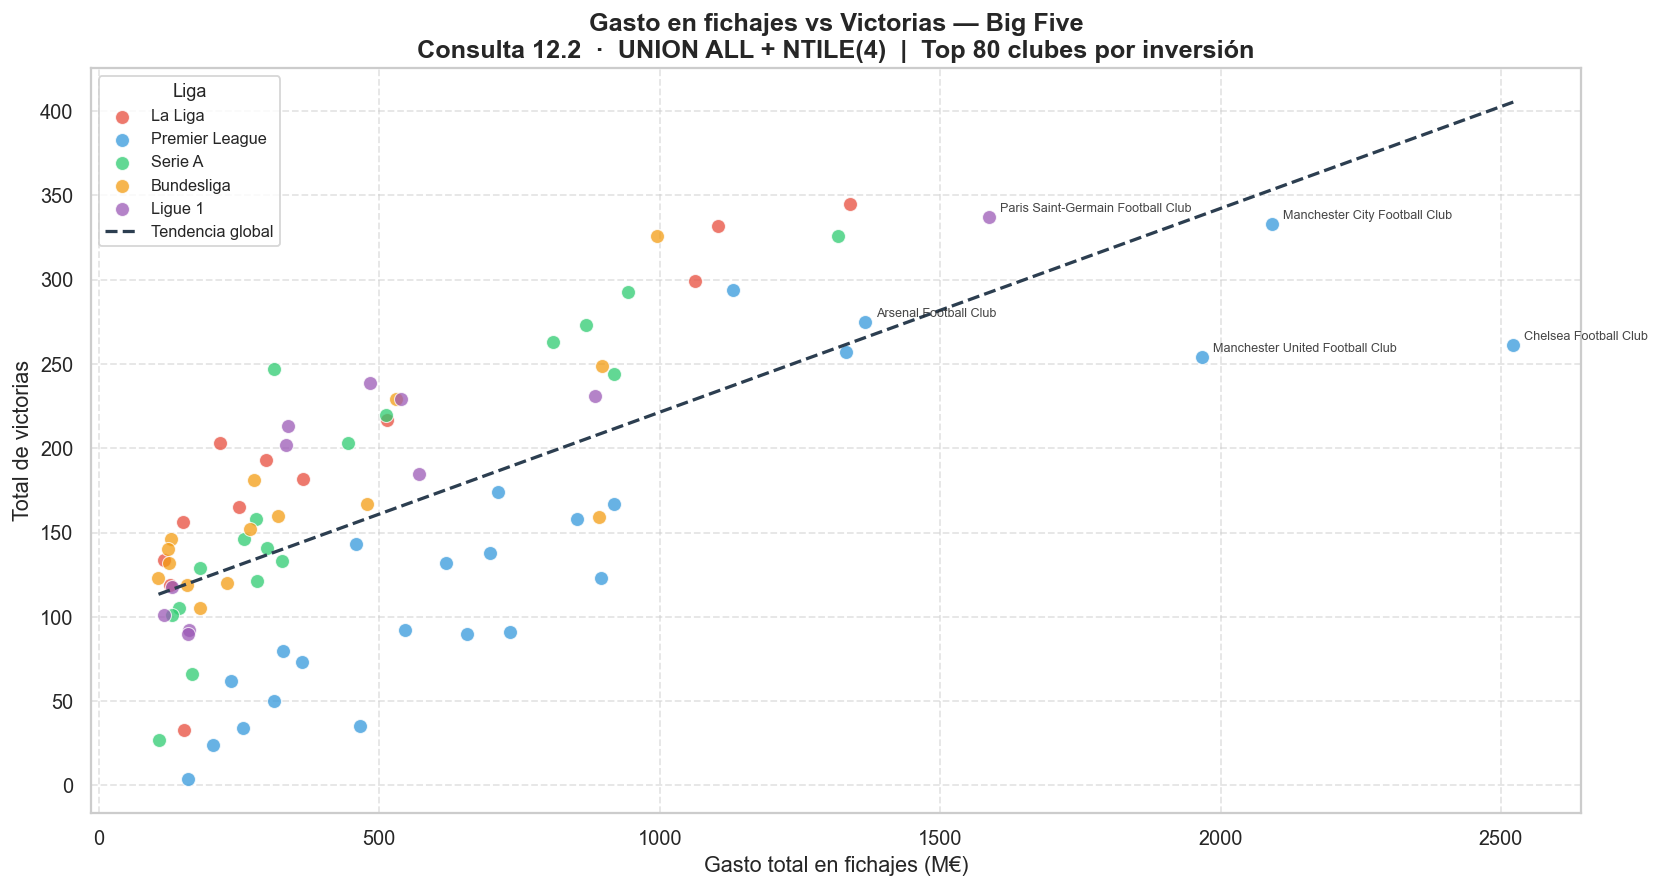

                                        club           liga  gasto_m  total_victorias  cuartil_gasto
                       Chelsea Football Club premier-league  2521.81            261.0              1
               Manchester City Football Club premier-league  2092.12            333.0              1
             Manchester United Football Club premier-league  1967.52            254.0              1
           Paris Saint-Germain Football Club        ligue-1  1587.82            337.0              1
                       Arsenal Football Club premier-league  1365.78            275.0              1
                       Futbol Club Barcelona         laliga  1338.79            345.0              1
             Tottenham Hotspur Football Club premier-league  1332.98            257.0              1
                      Juventus Football Club        serie-a  1318.30            326.0              1
                     Liverpool Football Club premier-league  1130.50            294.0      

In [30]:
# ── Consulta 12.2: Gasto en fichajes vs victorias (UNION ALL + NTILE) ───────
# Nota: PostgreSQL devuelve alias en minúsculas → gasto_m
SQL_GASTO_VIC = """
WITH gasto_por_club AS (
    SELECT
        c.club_id,
        c.name                                              AS club,
        comp.name                                           AS liga,
        ROUND(SUM(t.transfer_fee)::NUMERIC / 1e6, 2)       AS gasto_m
    FROM dwh.fact_transfers t
        INNER JOIN dwh.dim_clubs c   ON t.to_club_id = c.club_id
        LEFT JOIN dwh.dim_competitions comp ON c.domestic_competition_id = comp.competition_id
    WHERE comp.competition_id IN ('ES1','GB1','IT1','FR1','L1')
      AND c.club_id != -1
    GROUP BY c.club_id, c.name, comp.name
),
resultados_por_club AS (
    SELECT home_club_id AS club_id, COUNT(*) AS victorias
    FROM dwh.fact_games
    WHERE home_club_goals > away_club_goals
      AND competition_id IN ('ES1','GB1','IT1','FR1','L1')
    GROUP BY home_club_id
    UNION ALL
    SELECT away_club_id AS club_id, COUNT(*) AS victorias
    FROM dwh.fact_games
    WHERE away_club_goals > home_club_goals
      AND competition_id IN ('ES1','GB1','IT1','FR1','L1')
    GROUP BY away_club_id
),
victorias_totales AS (
    SELECT club_id, SUM(victorias) AS total_victorias
    FROM resultados_por_club
    GROUP BY club_id
),
ranking AS (
    SELECT
        g.club,
        g.liga,
        g.gasto_m,
        COALESCE(v.total_victorias, 0)                      AS total_victorias,
        NTILE(4) OVER (ORDER BY g.gasto_m DESC)             AS cuartil_gasto
    FROM gasto_por_club g
        LEFT JOIN victorias_totales v ON g.club_id = v.club_id
)
SELECT club, liga, gasto_m, total_victorias, cuartil_gasto
FROM ranking
ORDER BY gasto_m DESC
LIMIT 80;
"""

df_gasto = run_query(SQL_GASTO_VIC)
df_gasto['gasto_m']         = pd.to_numeric(df_gasto['gasto_m'],         errors='coerce')
df_gasto['total_victorias'] = pd.to_numeric(df_gasto['total_victorias'], errors='coerce')
df_gasto['cuartil_gasto']   = pd.to_numeric(df_gasto['cuartil_gasto'],   errors='coerce')

cuartil_palette = {1: '#e74c3c', 2: '#e67e22', 3: '#3498db', 4: '#27ae60'}
colores = df_gasto['cuartil_gasto'].map(cuartil_palette)

fig, ax = plt.subplots(figsize=(13, 7))

for liga_key in LIGA_ORDER:
    sub = df_gasto[df_gasto['liga'] == liga_key]
    if sub.empty:
        continue
    color = LIGA_COLORS.get(liga_key, '#95a5a6')
    label = LIGA_LABELS.get(liga_key, liga_key)
    ax.scatter(sub['gasto_m'], sub['total_victorias'],
               color=color, s=60, alpha=0.75, label=label, edgecolors='white', linewidths=0.6)

# Línea de tendencia global
valid = df_gasto.dropna(subset=['gasto_m', 'total_victorias'])
if len(valid) >= 2:
    m, b = np.polyfit(valid['gasto_m'], valid['total_victorias'], 1)
    xs = np.linspace(valid['gasto_m'].min(), valid['gasto_m'].max(), 200)
    ax.plot(xs, m * xs + b, '--', color='#2c3e50', linewidth=1.8, label='Tendencia global')

ax.set_xlabel('Gasto total en fichajes (M€)', fontsize=12)
ax.set_ylabel('Total de victorias', fontsize=12)
ax.set_title(
    'Gasto en fichajes vs Victorias — Big Five\n'
    'Consulta 12.2  ·  UNION ALL + NTILE(4)  |  Top 80 clubes por inversión',
    fontsize=14, fontweight='bold',
)
ax.legend(title='Liga', fontsize=9, title_fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

# Anotar los 5 clubes con mayor gasto
for _, row in df_gasto.head(5).iterrows():
    ax.annotate(
        row['club'],
        xy=(row['gasto_m'], row['total_victorias']),
        xytext=(6, 3), textcoords='offset points',
        fontsize=7, alpha=0.85,
    )

plt.tight_layout()
save_fig('viz_08_gasto_vs_victorias.png')
plt.show()
print(df_gasto[['club', 'liga', 'gasto_m', 'total_victorias', 'cuartil_gasto']].head(20).to_string(index=False))


---
## 9. ROLL-UP + WINDOW — ¿Cuál fue la temporada más goleadora por liga?
**Consulta 12.3** · Tablas: `fact_games`, `dim_date`, `dim_competitions`

La consulta define una CTE **`goles_por_temporada`** que agrupa partidos por (liga, temporada) y calcula el promedio de goles. Sobre ese conjunto aplica tres funciones de ventana simultáneas con `PARTITION BY liga`: `AVG(promedio_goles) OVER` para la media histórica, `RANK() OVER (ORDER BY promedio_goles DESC)` para identificar la temporada récord, y `MAX/MIN OVER` para los extremos históricos.

- **CTE previa:** `HAVING COUNT(*) >= 30` — descarta temporadas incompletas con menos de 30 partidos
- **`AVG() OVER (PARTITION BY liga)`:** media histórica de cada liga sin reducir las filas (no GROUP BY)
- **`RANK()` en lugar de `ROW_NUMBER()`:** aquí se permite empate; la visualización solo marca `rk_goleadora = 1` pero si dos temporadas empataran ambas se mostrarían como récord

**Operación OLAP:** `ROLL-UP` temporal (liga → temporada → promedio) + `WINDOW AVG/RANK/MAX/MIN OVER PARTITION` · **Visualización:** líneas de evolución por liga con ☆ dorada en la temporada récord y línea punteada de media histórica


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_09_temporada_goleadora.png


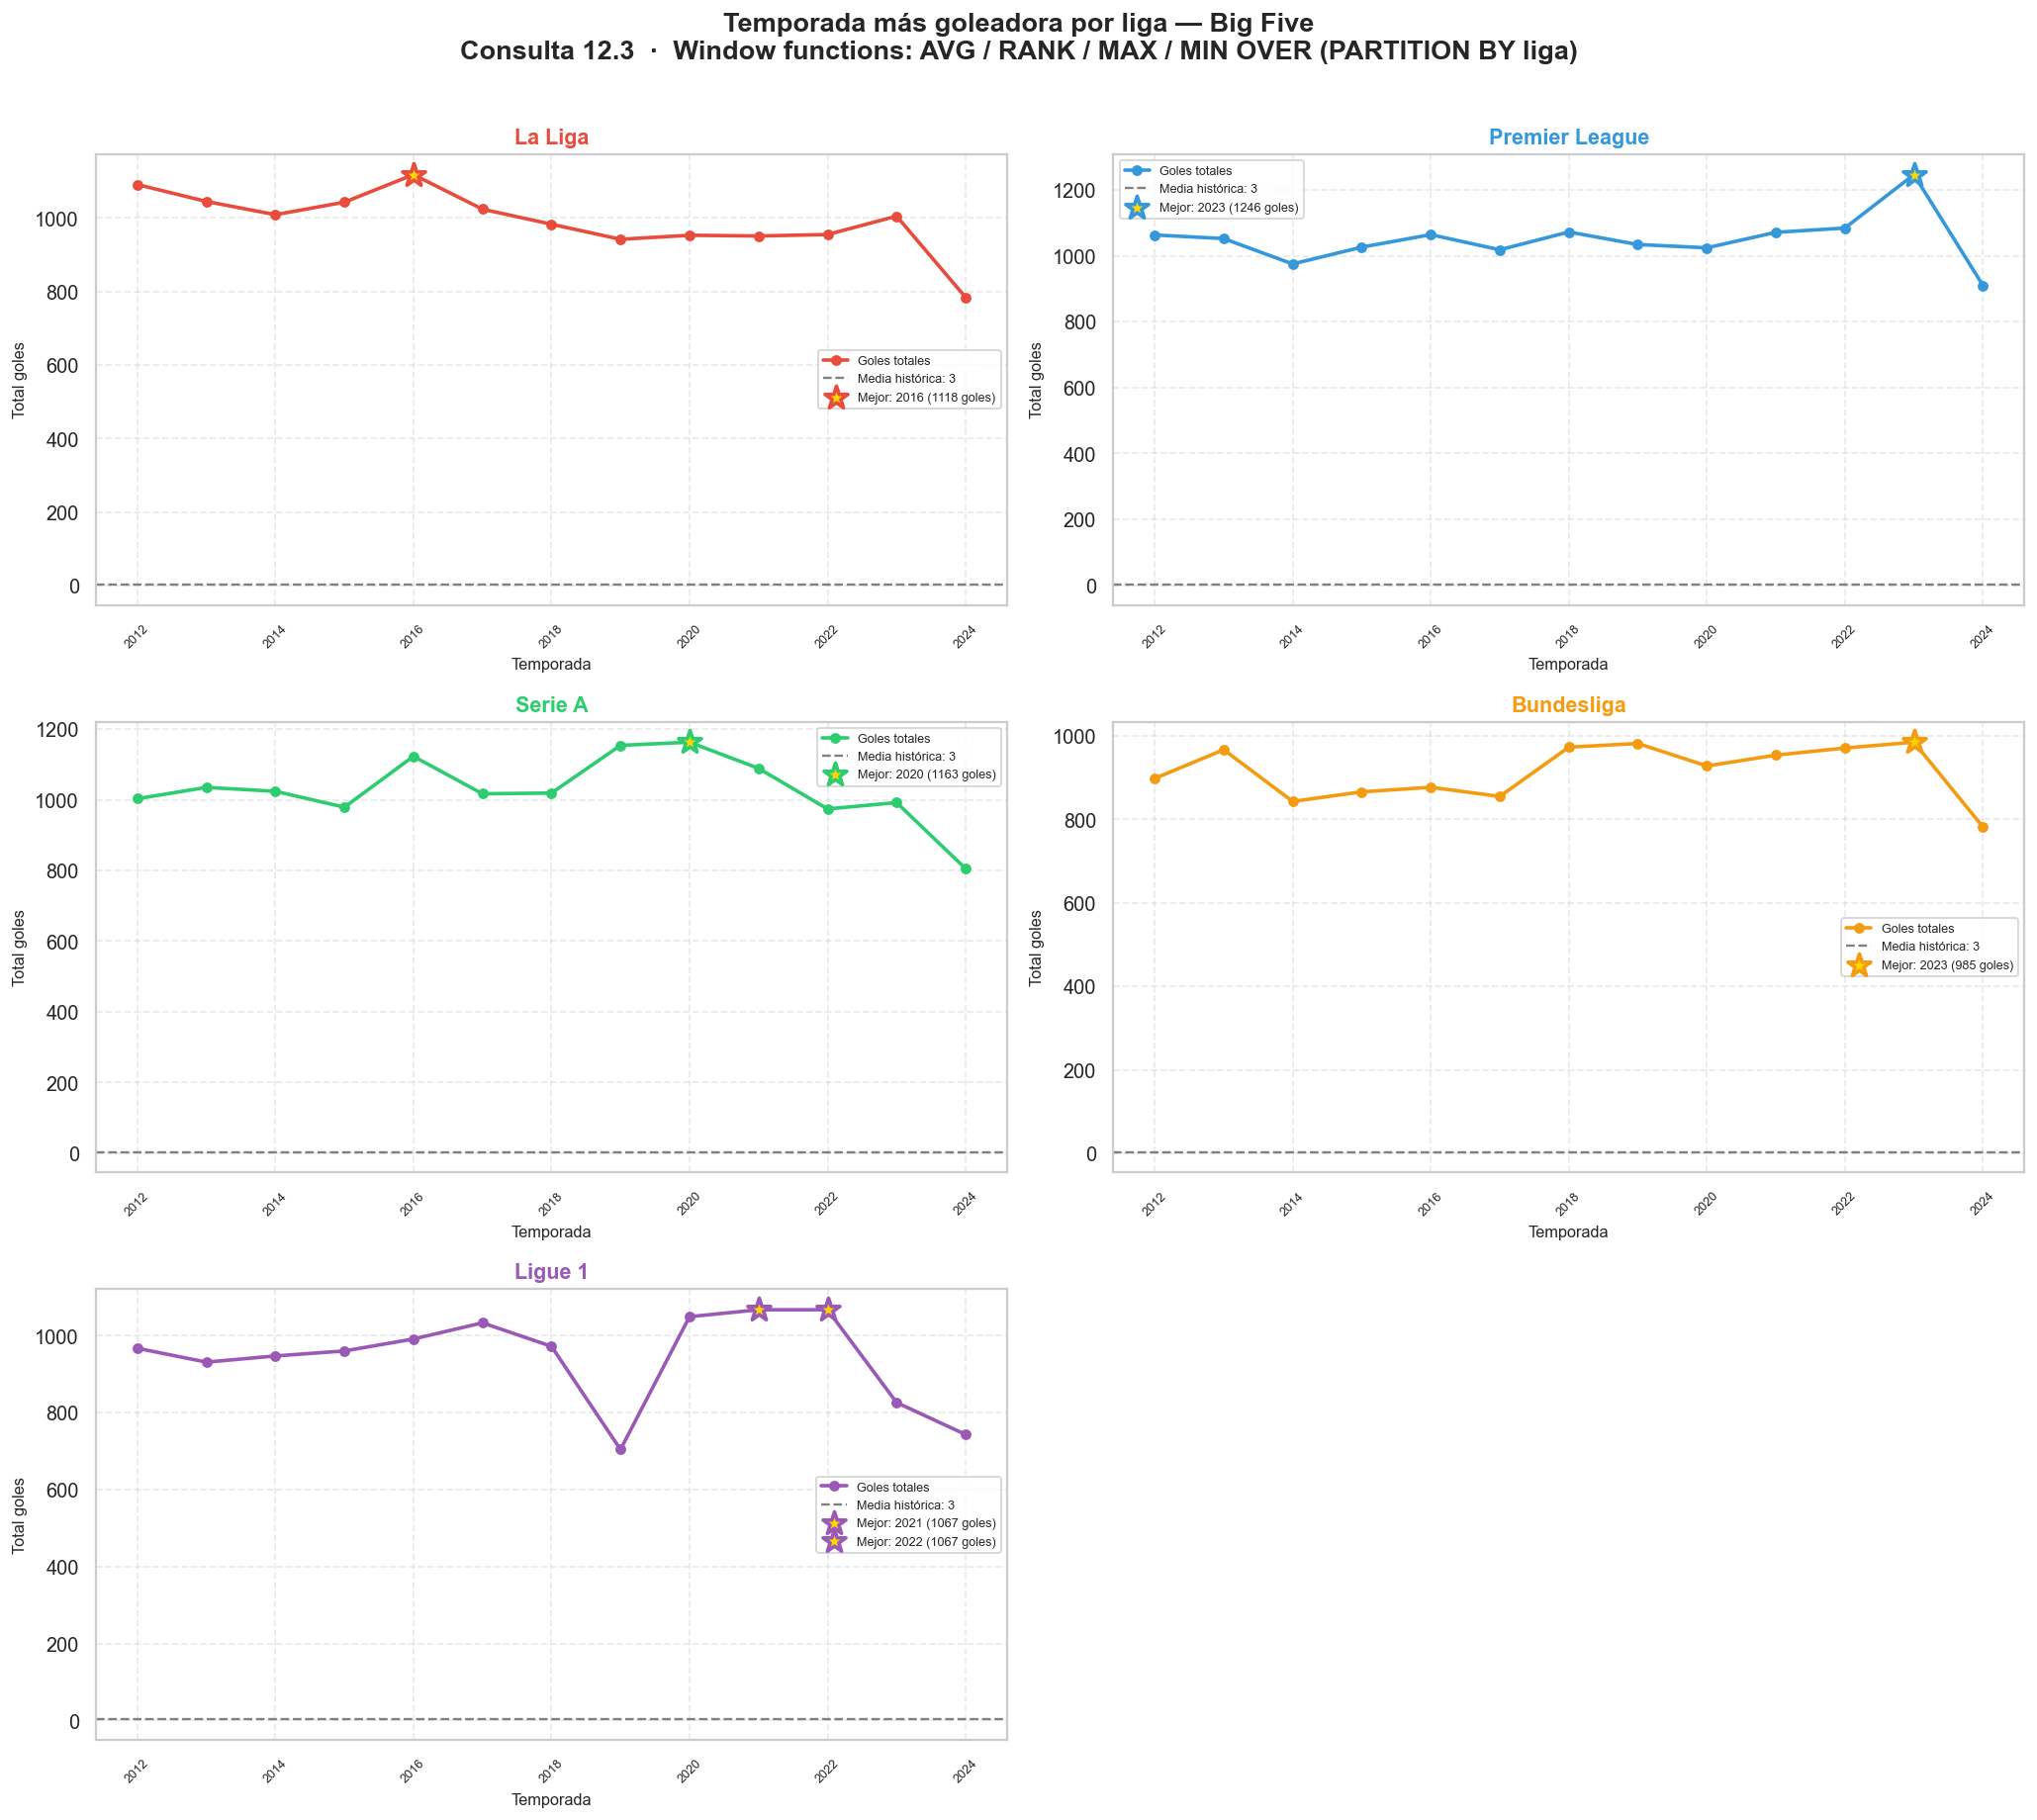

          liga  temporada  total_goles  media_historica
    bundesliga       2023          985             3.03
        laliga       2016         1118             2.65
       ligue-1       2021         1067             2.65
       ligue-1       2022         1067             2.65
premier-league       2023         1246             2.80
       serie-a       2020         1163             2.75


In [31]:
# ── Consulta 12.3: Temporada más goleadora por liga (Window functions) ───────
SQL_GOLEADORA = """
WITH goles_por_temporada AS (
    SELECT
        fg.competition_id,
        comp.name                                           AS liga,
        fg.season                                           AS temporada,
        SUM(fg.total_goals)                                 AS total_goles,
        COUNT(*)                                            AS num_partidos,
        ROUND(AVG(fg.total_goals)::NUMERIC, 2)              AS media_goles_partido
    FROM dwh.fact_games fg
        INNER JOIN dwh.dim_competitions comp ON fg.competition_id = comp.competition_id
    WHERE fg.competition_id IN ('ES1','GB1','IT1','FR1','L1')
    GROUP BY fg.competition_id, comp.name, fg.season
)
SELECT
    liga,
    temporada,
    total_goles,
    num_partidos,
    media_goles_partido,
    ROUND(AVG(media_goles_partido) OVER (PARTITION BY liga), 2)     AS media_historica,
    RANK() OVER (PARTITION BY liga ORDER BY total_goles DESC)       AS ranking_liga,
    MAX(total_goles) OVER (PARTITION BY liga)                       AS max_liga,
    MIN(total_goles) OVER (PARTITION BY liga)                       AS min_liga
FROM goles_por_temporada
ORDER BY liga, temporada;
"""

df_gol = run_query(SQL_GOLEADORA)
for col in ['total_goles', 'num_partidos', 'media_goles_partido', 'media_historica',
            'ranking_liga', 'max_liga', 'min_liga']:
    df_gol[col] = pd.to_numeric(df_gol[col], errors='coerce')

fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=False)
axes = axes.flatten()
fig.suptitle(
    'Temporada más goleadora por liga — Big Five\n'
    'Consulta 12.3  ·  Window functions: AVG / RANK / MAX / MIN OVER (PARTITION BY liga)',
    fontsize=15, fontweight='bold', y=1.01,
)

for i, liga_key in enumerate(LIGA_ORDER):
    ax = axes[i]
    sub = df_gol[df_gol['liga'] == liga_key].sort_values('temporada')
    if sub.empty:
        ax.set_visible(False)
        continue

    color  = LIGA_COLORS.get(liga_key, '#95a5a6')
    label  = LIGA_LABELS.get(liga_key, liga_key)
    media  = sub['media_historica'].iloc[0]
    mejor  = sub.loc[sub['ranking_liga'] == 1]

    ax.plot(sub['temporada'], sub['total_goles'],
            marker='o', linewidth=2, color=color, markersize=5, label='Goles totales')
    ax.axhline(media, linestyle='--', color='grey', linewidth=1.3, label=f'Media histórica: {media:.0f}')

    # Marcar la temporada más goleadora con una estrella
    for _, row in mejor.iterrows():
        ax.scatter(row['temporada'], row['total_goles'],
                   s=180, color='gold', edgecolors=color, linewidths=2, zorder=5,
                   marker='*', label=f"Mejor: {row['temporada']} ({int(row['total_goles'])} goles)")

    ax.set_title(label, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Temporada', fontsize=9)
    ax.set_ylabel('Total goles', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)

# Ocultar subplot sobrante
if len(LIGA_ORDER) < len(axes):
    for j in range(len(LIGA_ORDER), len(axes)):
        axes[j].set_visible(False)

plt.tight_layout()
save_fig('viz_09_temporada_goleadora.png')
plt.show()

mejor_por_liga = df_gol[df_gol['ranking_liga'] == 1][['liga', 'temporada', 'total_goles', 'media_historica']]
print(mejor_por_liga.to_string(index=False))


---
## 10. DICE + ROW_NUMBER — Top 20 partidos más espectaculares de la historia
**Consulta 12.4** · Tablas: `fact_games`, `dim_games`, `dim_date`, `dim_competitions`

La consulta aplica `ROW_NUMBER() OVER (ORDER BY fg.total_goals DESC, fg.goal_difference DESC)` sobre todos los partidos de las Big Five para extraer los 20 con más goles totales. El desempate secundario por `goal_difference` prioriza partidos más desequilibrados (un 10-0 antes que un 5-5 si ambos tienen 10 goles). Se añade la información de nombres de clubs desde `dim_games` y la fecha formateada con `TO_CHAR`.

- **`GROUP BY` completo:** necesario porque `fact_games` puede tener múltiples filas por partido en algunos entornos; el `GROUP BY game_id` y resto de atributos evita duplicados
- **`ROW_NUMBER` vs `RANK`:** `ROW_NUMBER` asegura exactamente 20 filas únicas (no habría filas extra por empate)
- **`TO_CHAR(d.full_date, 'DD/MM/YYYY')`:** formatea la fecha para la visualización tabular en español

> **Nota sobre Python:** `liga` recibido como clave BD lowercase; se mapea con `LIGA_LABELS` para mostrar el nombre legible en la tabla y con `liga_row_colors` para el color de fondo de fila.

**Operación OLAP:** `DICE` (Big Five) + `WINDOW ROW_NUMBER` · **Visualización:** tabla estilizada tipo marcador con color de fila por liga y resaltado rojo para partidos con ≥ 9 goles totales


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_10_partidos_espectaculares.png


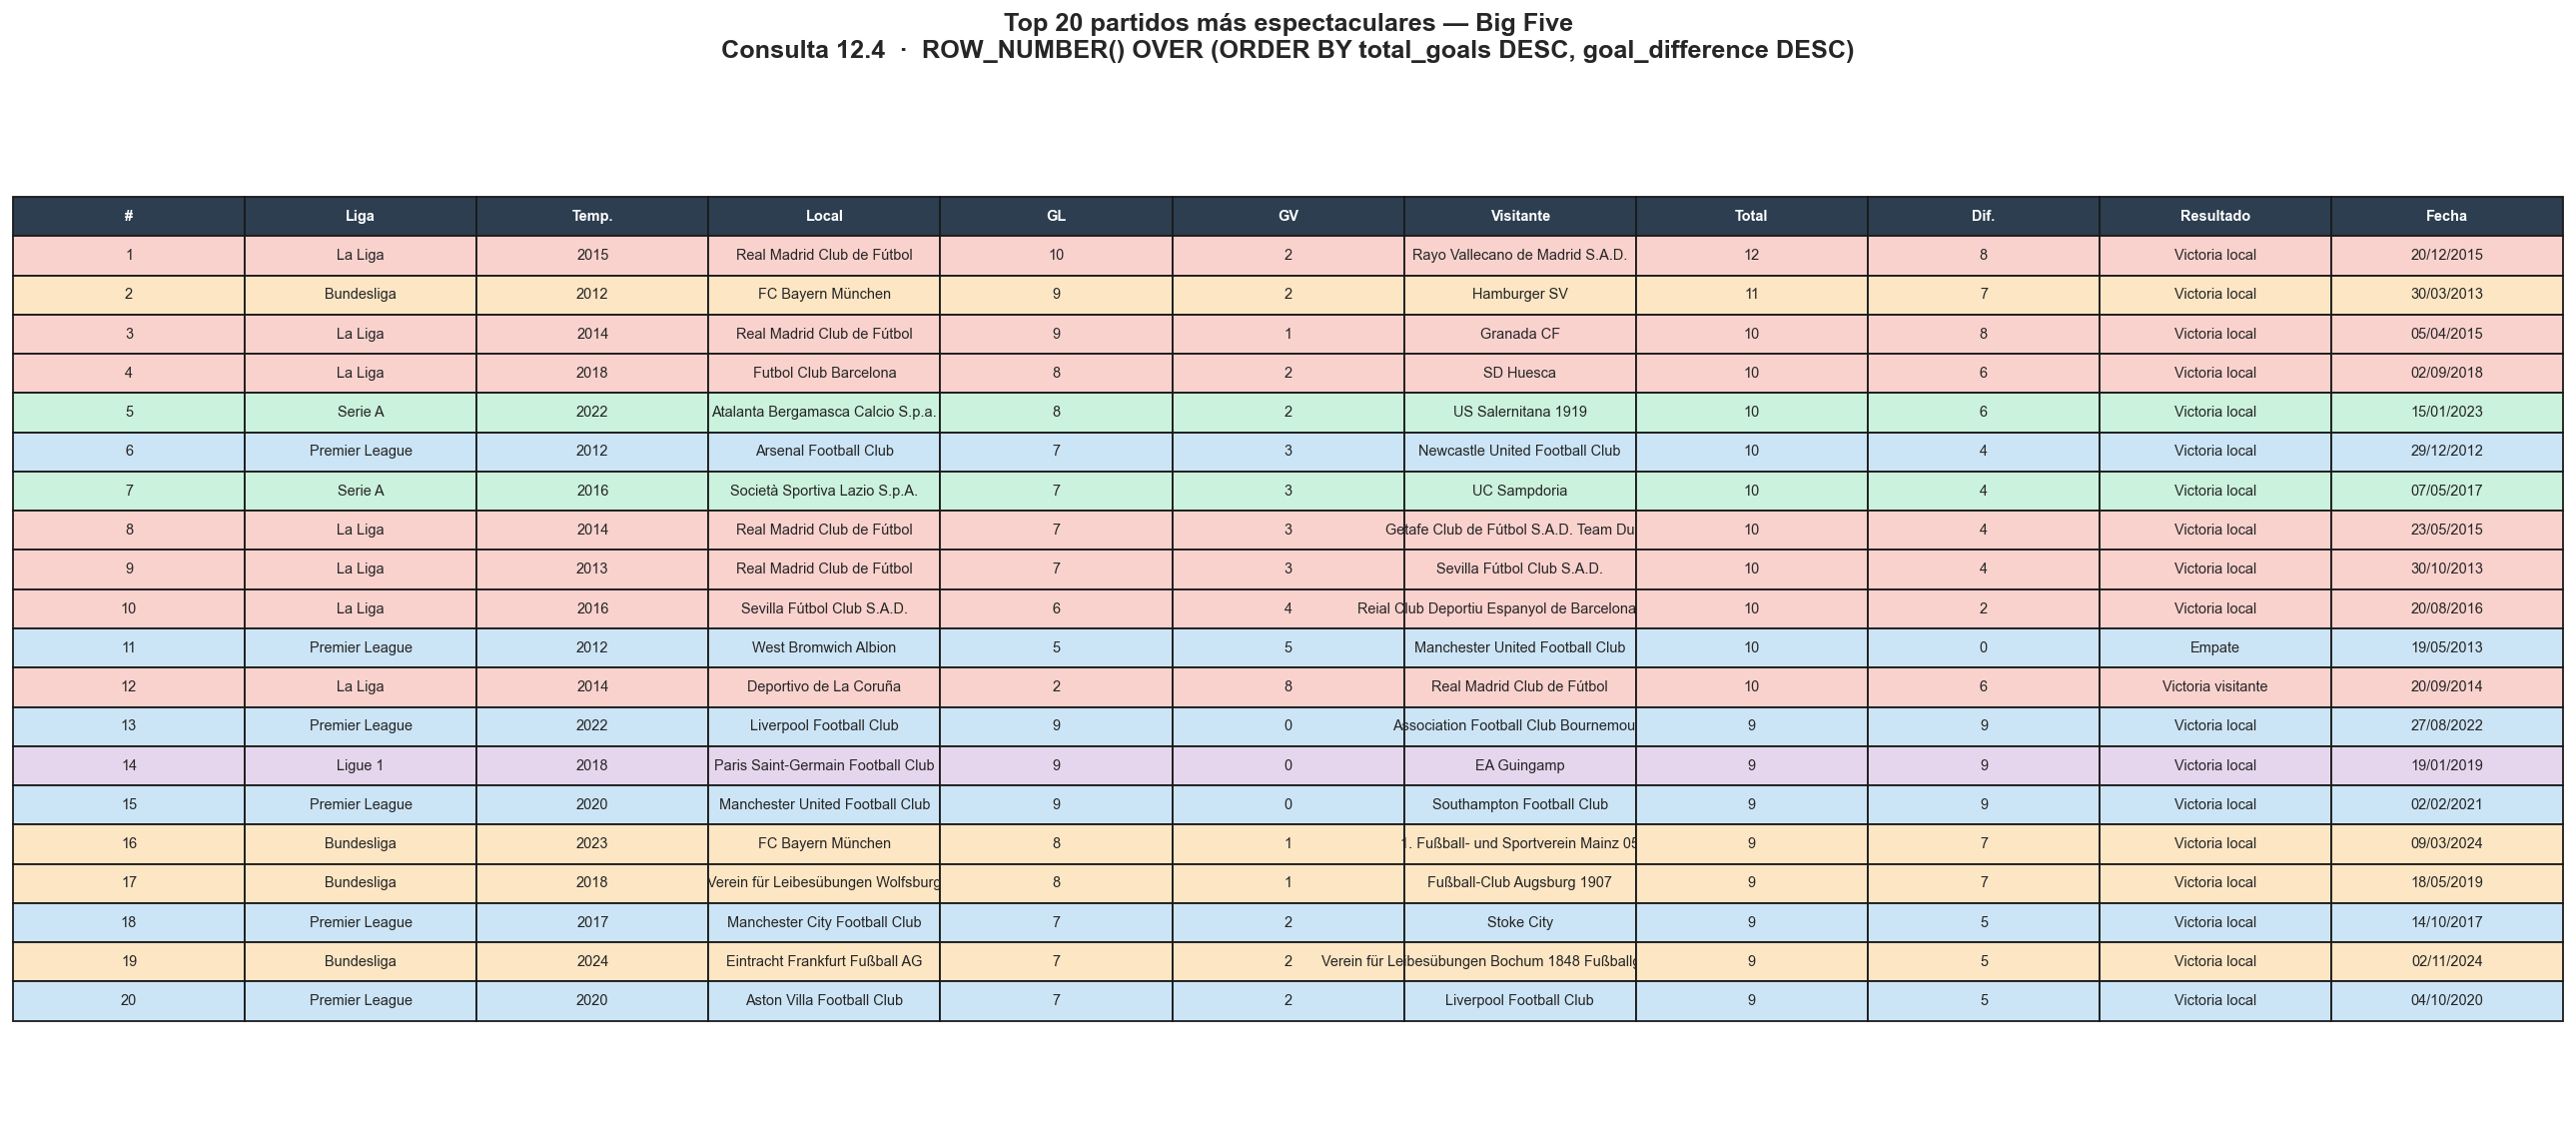

 ranking           liga  temporada                              local  goles_local  goles_visitante                                                visitante  total_goles
       1         laliga       2015         Real Madrid Club de Fútbol           10                2                          Rayo Vallecano de Madrid S.A.D.           12
       2     bundesliga       2012                  FC Bayern München            9                2                                             Hamburger SV           11
       3         laliga       2014         Real Madrid Club de Fútbol            9                1                                               Granada CF           10
       4         laliga       2018              Futbol Club Barcelona            8                2                                                SD Huesca           10
       5        serie-a       2022  Atalanta Bergamasca Calcio S.p.a.            8                2                                      US Salernitan

In [33]:
# ── Consulta 12.4: Top 20 partidos más espectaculares (ROW_NUMBER

SQL_ESPECTACULARES = """
SELECT
    ROW_NUMBER() OVER (ORDER BY fg.total_goals DESC, fg.goal_difference DESC)
                                                                    AS ranking,
    comp.name                                                       AS liga,
    TO_CHAR(d.full_date, 'DD/MM/YYYY')                              AS fecha,
    d.season_start_year                                             AS temporada,
    g.home_club_name                                                AS local,
    fg.home_club_goals                                              AS goles_local,
    fg.away_club_goals                                              AS goles_visitante,
    g.away_club_name                                                AS visitante,
    fg.total_goals                                                  AS total_goles,
    ABS(fg.goal_difference)                                         AS diferencia,
    CASE
        WHEN fg.is_home_win  THEN 'Victoria local'
        WHEN fg.is_away_win  THEN 'Victoria visitante'
        ELSE                      'Empate'
    END                                                             AS resultado
FROM dwh.fact_games fg
    INNER JOIN dwh.dim_games        g    ON fg.game_id        = g.game_id
    INNER JOIN dwh.dim_date         d    ON fg.date_id        = d.date_id
    INNER JOIN dwh.dim_competitions comp ON fg.competition_id = comp.competition_id
WHERE fg.competition_id IN ('ES1','GB1','IT1','FR1','L1')
ORDER BY fg.total_goals DESC, fg.goal_difference DESC
LIMIT 20;
"""

df_esp = run_query(SQL_ESPECTACULARES)
for col in ['goles_local', 'goles_visitante', 'total_goles', 'diferencia']:
    df_esp[col] = pd.to_numeric(df_esp[col], errors='coerce')

# Color de fila por liga (clave lowercase desde comp.name)
import matplotlib.colors as mcolors

liga_row_colors = []
for liga_val in df_esp['liga']:
    color = LIGA_COLORS.get(liga_val, '#bdc3c7')
    rgb   = mcolors.to_rgb(color)
    pastel = tuple(c * 0.25 + 0.75 for c in rgb)
    liga_row_colors.append(mcolors.to_hex(pastel))

fig, ax = plt.subplots(figsize=(20, 9))
ax.axis('off')

cols_show  = ['ranking', 'liga', 'temporada', 'local', 'goles_local',
              'goles_visitante', 'visitante', 'total_goles', 'diferencia', 'resultado', 'fecha']
col_labels = ['#', 'Liga', 'Temp.', 'Local', 'GL', 'GV', 'Visitante', 'Total', 'Dif.', 'Resultado', 'Fecha']

# Mostrar nombre legible de liga
df_display = df_esp.copy()
df_display['liga'] = df_display['liga'].map(LIGA_LABELS).fillna(df_display['liga'])

cell_data   = df_display[cols_show].astype(str).values.tolist()
cell_colors = [[liga_row_colors[i]] * len(cols_show) for i in range(len(df_esp))]

tbl = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    cellColours=cell_colors,
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.55)

# Cabecera oscura
for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor('#2c3e50')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

ax.set_title(
    'Top 20 partidos más espectaculares — Big Five\n'
    'Consulta 12.4  ·  ROW_NUMBER() OVER (ORDER BY total_goals DESC, goal_difference DESC)',
    fontsize=14, fontweight='bold', pad=14,
)

plt.tight_layout()
save_fig('viz_10_partidos_espectaculares.png')
plt.show()
print(df_esp[['ranking', 'liga', 'temporada', 'local', 'goles_local', 'goles_visitante', 'visitante', 'total_goles']].to_string(index=False))
